# Homework 5: Portfolio Construction

In [44]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
import cvxpy as cp
import statsmodels.api as sm

%matplotlib inline
pd.set_option('display.max_columns', 50)
pd.set_option('display.float_format', '{:.6f}'.format)

## Loading data and checking there are no duplicate keys 

In [45]:
# Load data
data_df = pd.read_excel('data.xlsx')
factors_df = pd.read_excel('factors.xlsx')
estimates_df = pd.read_excel('estimates.xlsx')

# Normalize key dtypes first (same keys we will use for indexes) — then check uniqueness.
data_df['date'] = pd.to_datetime(data_df['date'])
factors_df['date'] = pd.to_datetime(factors_df['date'])

# --- Duplicate key checks BEFORE set_index (prevents ambiguous rows / silent drops) ---
_dup_data = data_df.duplicated(subset=['date', 'mrap_id'], keep=False)
n_dup_data = int(_dup_data.sum())
if n_dup_data:
    raise ValueError(
        f"data.xlsx: {n_dup_data} rows lie in duplicate (date, mrap_id) groups. "
        "Fix the file or dedupe before indexing."
    )

_dup_fac = factors_df.duplicated(subset=['date'], keep=False)
n_dup_fac = int(_dup_fac.sum())
if n_dup_fac:
    raise ValueError(
        f"factors.xlsx: {n_dup_fac} rows lie in duplicate date groups. "
        "Fix the file or dedupe before indexing."
    )

_dup_est = estimates_df.duplicated(subset=['mrap_id'], keep=False)
n_dup_est = int(_dup_est.sum())
if n_dup_est:
    raise ValueError(
        f"estimates.xlsx: {n_dup_est} rows lie in duplicate mrap_id groups. "
        "Fix the file or dedupe before indexing."
    )

print(
    "Duplicate-key checks passed: "
    "data (date, mrap_id), factors (date), estimates (mrap_id) are unique."
)




Duplicate-key checks passed: data (date, mrap_id), factors (date), estimates (mrap_id) are unique.


## Re-indexing data 

In [46]:
# Panel indices: time-first where applicable; cross-section ids on mrap_id for estimates.
factors_df = factors_df.set_index('date').sort_index()

estimates_df = estimates_df.set_index('mrap_id').sort_index()

data_df = (
    data_df
    .set_index(['date', 'mrap_id'])
    .sort_index()
)

print("data.xlsx shape (rows, cols):", data_df.shape)
print("factors.xlsx shape (rows, cols):", factors_df.shape)
print("estimates.xlsx shape (rows, cols):", estimates_df.shape)

display(data_df.head())
display(factors_df.head())
display(estimates_df.head())

data.xlsx shape (rows, cols): (95631, 5)
factors.xlsx shape (rows, cols): (108, 6)
estimates.xlsx shape (rows, cols): (1000, 5)


naics     price           vol       ret  \
date       mrap_id                                                   
2031-01-31 201     325414.000000  5.170000  18352.000000  0.102345   
           224     334516.000000 25.580000 200854.000000 -0.006584   
           377     325320.000000 51.669998 119178.000000  0.017727   
           421     541512.000000 34.259998  49790.000000 -0.058015   
           519     518210.000000 19.059999  10205.000000 -0.112663   

                          shrout  
date       mrap_id                
2031-01-31 201      30787.000000  
           224     118045.000000  
           377      66557.000000  
           421     108715.000000  
           519      29438.000000

,factor_1,factor_2,factor_3,factor_4,factor_5,rf
date,,,,,,
2031-01-31,0.019900,-0.024300,0.008200,-0.007600,0.008300,0.000100
2031-02-28,0.034900,0.016500,0.012700,-0.019400,0.008800,0.000100
2031-03-31,0.004600,0.026200,-0.018300,0.017600,-0.000300,0.000100
2031-04-29,0.029000,-0.005500,-0.024300,0.010100,-0.008000,0.000000
2031-05-31,-0.012700,-0.006200,-0.021200,0.020800,-0.015800,0.000000


,naics,price,ret,shrout,pred
mrap_id,,,,,
61,515210,28.980000,-0.045455,218693,0.065368
181,541715,45.980000,0.107952,68084,0.016078
201,325414,193.990010,0.024234,55771,0.206953
224,334510,109.590000,0.022486,123530,0.019844
377,561730,65.700000,0.179524,56692,0.021738


### Normalizing units

In [47]:
# =============================================================================
# Unit normalization — apply once here so all downstream cells use real units
# =============================================================================
# data.xlsx:     vol    is in 00's  → multiply × 100 for actual shares traded
#                shrout is in 000's → multiply × 1000 for actual shares outstanding
# estimates.xlsx shrout is in 000's → same adjustment

data_df['vol']    = data_df['vol']    * 100
data_df['shrout'] = data_df['shrout'] * 1000
estimates_df['shrout'] = estimates_df['shrout'] * 1000

print("Unit normalization applied:")
print(f"  data_df['vol']         now in actual shares  (sample max: {data_df['vol'].max():,.0f})")
print(f"  data_df['shrout']      now in actual shares  (sample max: {data_df['shrout'].max():,.0f})")
print(f"  estimates_df['shrout'] now in actual shares  (sample max: {estimates_df['shrout'].max():,.0f})")


Unit normalization applied:
  data_df['vol']         now in actual shares  (sample max: 12,703,910,900)
  data_df['shrout']      now in actual shares  (sample max: 29,206,400,000)
  estimates_df['shrout'] now in actual shares  (sample max: 15,441,881,000)


## Data quality and exploratory checks

The cells below run **independent** checks on the raw inputs (`data.xlsx`, `factors.xlsx`, `estimates.xlsx`).  
Each section has a short description and a single code cell so you can re-run or skip checks easily. **After the calendar-alignment check**, run **sample cleaning** (prices, min return-month count), then continue to the analysis section.

| # | What we check |
|---|----------------|
| 1 | Missing values by column |
| 2 | Nonsensical returns and sign issues (e.g. negative price) |
| 3 | **Return panel** — EDA plots: raw vs calendar coverage, contiguous vs interior-gap, segment counts |
| 4 | Stale / repeated prices |
| 5 | Return distribution and outliers |
| 6 | Cross-file ID coverage and NAICS in estimates |
| 7 | Calendar alignment: data vs factor dates |


### Check 1 — Missing values


In [48]:
# Check 1 — Missing values per column
print("=== Check 1: Missing values per column ===")
for name, df in [('data', data_df), ('factors', factors_df), ('estimates', estimates_df)]:
    missing = df.isnull().sum()
    missing = missing[missing > 0]
    if len(missing):
        print(f"\n{name}.xlsx:")
        print(missing.to_string())
    else:
        print(f"\n{name}.xlsx: no missing values")


=== Check 1: Missing values per column ===

data.xlsx:
naics     634
price     510
vol       504
ret       738
shrout    203

factors.xlsx: no missing values

estimates.xlsx: no missing values


### Check 2 — Nonsensical returns and bad inputs


In [49]:
# Check 2 — Nonsensical returns and invalid inputs
print("=== Check 2: Nonsensical returns / bad inputs ===")
print(f"Returns < -1.0 (> 100% loss) : {(data_df['ret'] < -1.0).sum()}")
print(f"Returns > 5.0 (> 500% gain): {(data_df['ret'] > 5.0).sum()}")
print(f"Negative prices              : {(data_df['price'] < 0).sum()}")
print(f"Negative volume              : {(data_df['vol'] < 0).sum()}")
print(f"Non-positive shares (shrout) : {(data_df['shrout'] <= 0).sum()}")


=== Check 2: Nonsensical returns / bad inputs ===
Returns < -1.0 (> 100% loss) : 0
Returns > 5.0 (> 500% gain): 0
Negative prices              : 30
Negative volume              : 0
Non-positive shares (shrout) : 0


**Clearly we have negative prices that we have to handle.**

### Check 3 — Return panel (raw coverage + factor-calendar continuity)

This replaces the old split between “observations per stock” and “factor-calendar gaps”. **Check 3 is exploratory:** we **classify** each `mrap_id` and **plot** return-panel shape (contiguous vs sporadic re-entry). We **do not** drop names here.

**Classification:** **(i)** raw monthly rows in the long file, **(ii)** non-missing months after aligning to the **factor calendar**, **(iii)** whether missing months are only **leading/trailing** (IPO / delist) or include **interior holes** (returns disappear then reappear). **Segment count** (`n_seg`) counts disjoint spells of valid months on the calendar—values $\geq 2$ often mean separate listed spells (e.g. delist → private → re-IPO under one id) or bad merges; we cannot tell without corporate actions.


=== Check 3: Return panel (raw + factor calendar + continuity) ===
Factor calendar length T = 108
Stocks in wide matrix: 1000

--- Classification on factor calendar ---
  Full contiguous panel (all T months observed):     771
  Partial but contiguous (IPO/delist edges only):  225
  Interior missing months (non-contiguous span):   4

--- Segment count on calendar (among interior-gap names) ---
0    1
2    3
  (n_seg >= 2: multiple disjoint spells — re-listing vs data holes.)

--- Raw file rows vs calendar non-miss (dates outside factor calendar) ---
  Stocks where raw_rows != cal_nonmiss: 229

--- Raw monthly row counts (long file) ---
count   1000.000000
mean      95.631000
std       26.822608
min        2.000000
25%      108.000000
50%      108.000000
75%      108.000000
max      108.000000

Stocks with raw_rows == 108: 778
Stocks with raw_rows < 36 : 70


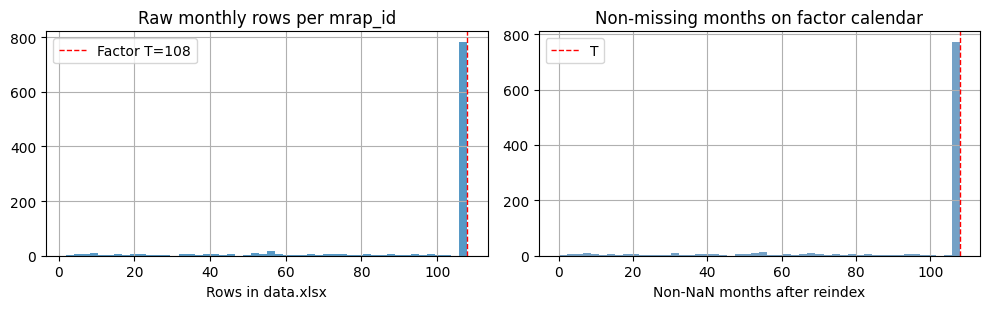

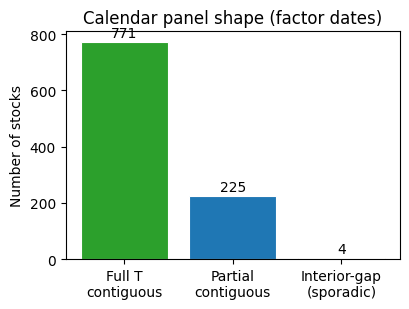

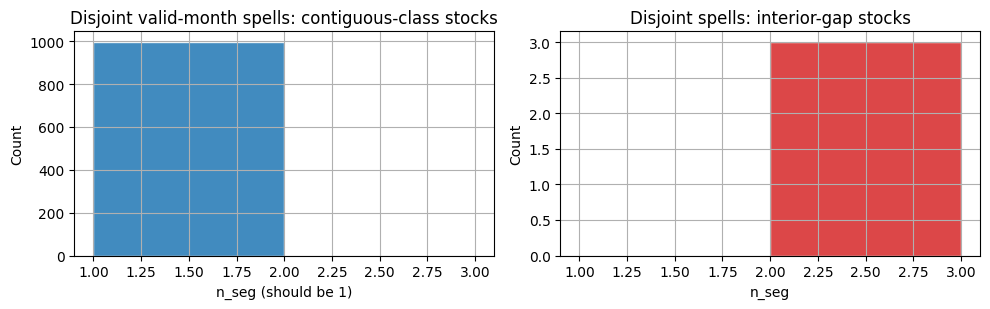

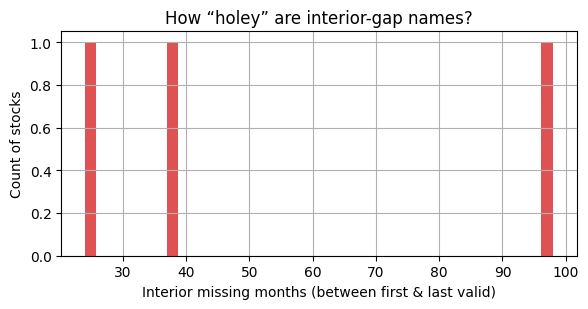

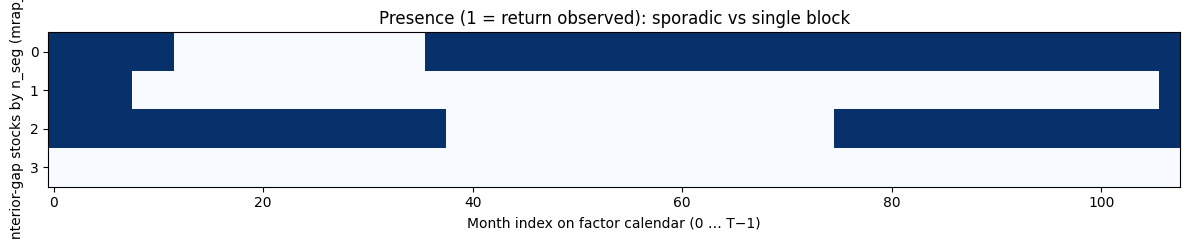

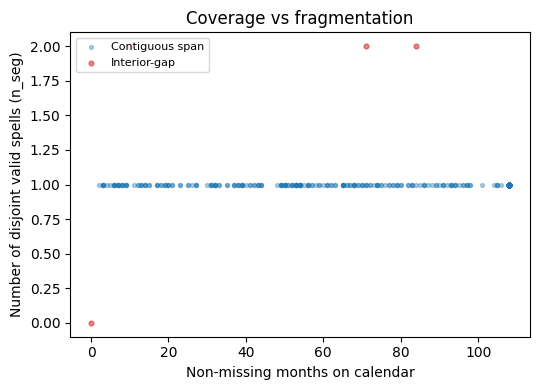

In [50]:
# Check 3 — Return panel: classify + visualize (no dropping here)

def _return_panel_has_interior_gap(row: pd.Series) -> bool:
    """True if any calendar month is missing *between* the first and last observed return."""
    v = row.notna().to_numpy()
    if not v.any():
        return True
    first = int(np.argmax(v))
    last = int(len(v) - 1 - np.argmax(v[::-1]))
    return not bool(v[first : last + 1].all())


def _count_valid_segments(row: pd.Series) -> int:
    """Number of disjoint runs of non-NaN months on the factor calendar (0 if never present)."""
    v = row.notna().to_numpy()
    if not v.any():
        return 0
    w = v.astype(np.int8)
    d = np.diff(np.r_[0, w, 0])
    return int((d == 1).sum())


def _interior_hole_months(row: pd.Series) -> float:
    """Count of missing months strictly between first and last valid return (0 if none / empty)."""
    v = row.notna().to_numpy()
    if not v.any():
        return np.nan
    first = int(np.argmax(v))
    last = int(len(v) - 1 - np.argmax(v[::-1]))
    span = v[first : last + 1]
    return float((~span).sum())


_dates_panel = sorted(factors_df.index.unique())
T_cal = len(_dates_panel)
R_wide = data_df['ret'].unstack(level='date').reindex(columns=_dates_panel)

raw_obs = data_df.groupby(level='mrap_id').size()
cal_obs = R_wide.notna().sum(axis=1)
interior_gap = R_wide.apply(_return_panel_has_interior_gap, axis=1)
n_segments = R_wide.apply(_count_valid_segments, axis=1)
hole_months = R_wide.apply(_interior_hole_months, axis=1)

both = pd.DataFrame({
    'raw_rows': raw_obs,
    'cal_nonmiss': cal_obs,
    'interior_gap': interior_gap,
    'n_seg': n_segments,
    'hole_months': hole_months,
}).reindex(R_wide.index)

mismatch = both['raw_rows'] != both['cal_nonmiss']
n_mismatch = int(mismatch.sum())

full_cal = (~interior_gap) & (both['cal_nonmiss'] == T_cal)
partial_cont = (~interior_gap) & (both['cal_nonmiss'] < T_cal)
gappy = interior_gap

print("=== Check 3: Return panel (raw + factor calendar + continuity) ===")
print(f"Factor calendar length T = {T_cal}")
print(f"Stocks in wide matrix: {len(R_wide)}")
print()
print("--- Classification on factor calendar ---")
print(f"  Full contiguous panel (all T months observed):     {int(full_cal.sum())}")
print(f"  Partial but contiguous (IPO/delist edges only):  {int(partial_cont.sum())}")
print(f"  Interior missing months (non-contiguous span):   {int(gappy.sum())}")
print()
print("--- Segment count on calendar (among interior-gap names) ---")
if gappy.any():
    sg = n_segments[gappy]
    print(sg.value_counts().sort_index().head(15).to_string())
    print("  (n_seg >= 2: multiple disjoint spells — re-listing vs data holes.)")
print()
print(f"--- Raw file rows vs calendar non-miss (dates outside factor calendar) ---")
print(f"  Stocks where raw_rows != cal_nonmiss: {n_mismatch}")
if n_mismatch and n_mismatch <= 20:
    print(both.loc[mismatch, ['raw_rows', 'cal_nonmiss']].head(20).to_string())
print()
print("--- Raw monthly row counts (long file) ---")
print(raw_obs.describe().to_string())
print(f"\nStocks with raw_rows == {T_cal}: {(raw_obs == T_cal).sum()}")
print(f"Stocks with raw_rows < 36 : {(raw_obs < 36).sum()}")

# --- Figures: panel shape (contiguous vs sporadic) ---
fig, axes = plt.subplots(1, 2, figsize=(10, 3.2))
raw_obs.hist(bins=50, ax=axes[0], edgecolor='none', alpha=0.75)
axes[0].set_title('Raw monthly rows per mrap_id')
axes[0].set_xlabel('Rows in data.xlsx')
axes[0].axvline(T_cal, color='red', ls='--', lw=1, label=f'Factor T={T_cal}')
axes[0].legend()

cal_obs.hist(bins=50, ax=axes[1], edgecolor='none', alpha=0.75, color='steelblue')
axes[1].set_title('Non-missing months on factor calendar')
axes[1].set_xlabel('Non-NaN months after reindex')
axes[1].axvline(T_cal, color='red', ls='--', lw=1, label='T')
axes[1].legend()
plt.tight_layout()
plt.show()

fig, ax = plt.subplots(figsize=(4.2, 3.2))
cats = ['Full T\ncontiguous', 'Partial\ncontiguous', 'Interior-gap\n(sporadic)']
counts = [int(full_cal.sum()), int(partial_cont.sum()), int(gappy.sum())]
colors = ['#2ca02c', '#1f77b4', '#d62728']
ax.bar(cats, counts, color=colors, edgecolor='white', lw=0.8)
ax.set_ylabel('Number of stocks')
ax.set_title('Calendar panel shape (factor dates)')
for i, c in enumerate(counts):
    ax.text(i, c + max(counts) * 0.01, str(c), ha='center', va='bottom', fontsize=10)
plt.tight_layout()
plt.show()

fig, axes = plt.subplots(1, 2, figsize=(10, 3.2))
if (~gappy).any():
    nmax = int(n_segments.max()) + 2
    n_segments.loc[~gappy].hist(bins=range(1, max(3, nmax)), ax=axes[0], color='#1f77b4', alpha=0.85, edgecolor='white')
    axes[0].set_title('Disjoint valid-month spells: contiguous-class stocks')
else:
    axes[0].text(0.5, 0.5, 'No contiguous-class stocks', ha='center', va='center', transform=axes[0].transAxes)
    axes[0].set_title('Contiguous-class (n_seg)')
axes[0].set_xlabel('n_seg (should be 1)')
axes[0].set_ylabel('Count')
if gappy.any():
    ub = min(20, int(n_segments[gappy].max()) + 2)
    n_segments.loc[gappy].hist(bins=range(1, max(3, ub)), ax=axes[1], color='#d62728', alpha=0.85, edgecolor='white')
    axes[1].set_title('Disjoint spells: interior-gap stocks')
else:
    axes[1].text(0.5, 0.5, 'No interior-gap stocks', ha='center', va='center', transform=axes[1].transAxes)
    axes[1].set_title('Interior-gap (n_seg)')
axes[1].set_xlabel('n_seg')
axes[1].set_ylabel('Count')
plt.tight_layout()
plt.show()

if gappy.any():
    hm = hole_months[gappy].dropna()
    fig, ax = plt.subplots(figsize=(6, 3.2))
    hm.hist(bins=40, ax=ax, color='#d62728', alpha=0.8, edgecolor='none')
    ax.set_xlabel('Interior missing months (between first & last valid)')
    ax.set_ylabel('Count of stocks')
    ax.set_title('How “holey” are interior-gap names?')
    plt.tight_layout()
    plt.show()

    # Calendar presence: subset with most disjoint spells (read as time along x)
    k = min(30, int(gappy.sum()))
    sample_idx = n_segments[gappy].sort_values(ascending=False).head(k).index
    Z = R_wide.loc[sample_idx].notna().astype(np.float32).values
    fig, ax = plt.subplots(figsize=(12, max(2.5, k * 0.18)))
    ax.imshow(Z, aspect='auto', cmap='Blues', vmin=0, vmax=1, interpolation='nearest')
    ax.set_xlabel('Month index on factor calendar (0 … T−1)')
    ax.set_ylabel(f'Top {k} interior-gap stocks by n_seg (mrap_id order)')
    ax.set_title('Presence (1 = return observed): sporadic vs single block')
    plt.tight_layout()
    plt.show()

fig, ax = plt.subplots(figsize=(5.5, 4))
ok = ~(gappy) & (cal_obs > 0)
ax.scatter(cal_obs.loc[ok], n_segments.loc[ok], s=8, alpha=0.35, c='#1f77b4', label='Contiguous span')
if gappy.any():
    ax.scatter(cal_obs.loc[gappy], n_segments.loc[gappy], s=12, alpha=0.55, c='#d62728', label='Interior-gap')
ax.set_xlabel('Non-missing months on calendar')
ax.set_ylabel('Number of disjoint valid spells (n_seg)')
ax.legend(loc='upper left', fontsize=8)
ax.set_title('Coverage vs fragmentation')
plt.tight_layout()
plt.show()


### Check 4 — Stale or repeated prices


In [51]:
# Check 5 — Stale / repeated month-end prices
print("=== Check 5: Stale prices (many identical month-end prices per stock) ===")
price_changes = data_df.groupby(level='mrap_id', sort=False)['price'].apply(
    lambda s: (s.droplevel('mrap_id').sort_index().diff().abs() < 1e-8).sum()
)
stale_stocks = price_changes[price_changes > 2]
print(f"Stocks with >2 zero price changes: {len(stale_stocks)}")
if len(stale_stocks) > 0:
    print(stale_stocks.sort_values(ascending=False).head(10))


=== Check 5: Stale prices (many identical month-end prices per stock) ===
Stocks with >2 zero price changes: 5
mrap_id
28751    5
34642    3
42988    3
66474    3
46931    3
Name: price, dtype: int64


### Check 5 — Return distribution and outliers


=== Check 6: Return distribution (data.xlsx) ===
count   94893.000000
mean        0.014904
std         0.094922
min        -0.878327
1%         -0.223495
5%         -0.125000
25%        -0.033569
50%         0.014090
75%         0.060158
95%         0.154444
99%         0.277847
max         4.163793


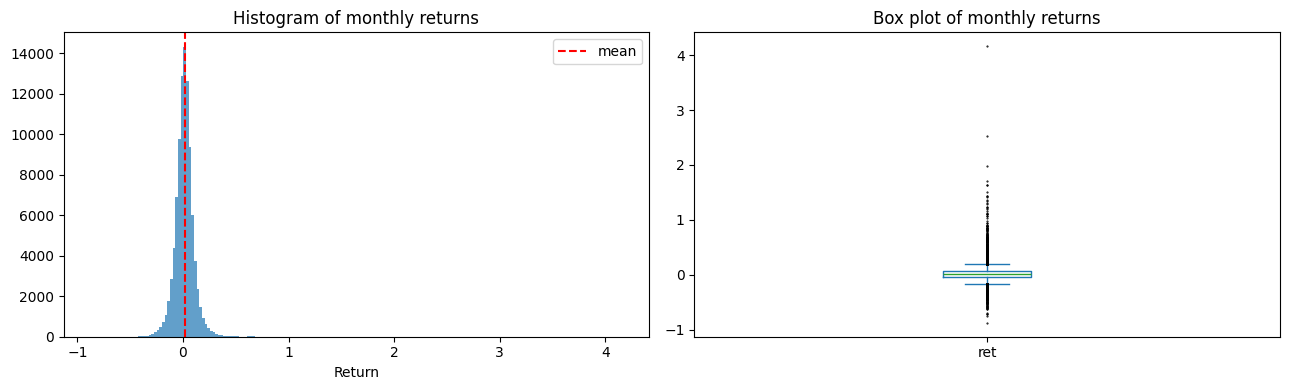

In [52]:
# Check 6 — Return distribution and extreme tails
print("=== Check 6: Return distribution (data.xlsx) ===")
ret_desc = data_df['ret'].describe(percentiles=[0.01, 0.05, 0.25, 0.5, 0.75, 0.95, 0.99])
print(ret_desc.to_string())

fig, axes = plt.subplots(1, 2, figsize=(13, 4))
axes[0].hist(data_df['ret'].dropna(), bins=200, edgecolor='none', alpha=0.7)
axes[0].set_title('Histogram of monthly returns')
axes[0].set_xlabel('Return')
axes[0].axvline(data_df['ret'].mean(), color='red', ls='--', label='mean')
axes[0].legend()

data_df['ret'].dropna().plot.box(ax=axes[1], vert=True, sym='k.', flierprops=dict(markersize=1))
axes[1].set_title('Box plot of monthly returns')
plt.tight_layout()
plt.show()


### Check 6 — Cross-file ID coverage and NAICS


In [53]:
# Check 7 — Cross-file ID coverage
data_ids  = set(data_df.index.get_level_values('mrap_id').unique())
est_ids   = set(estimates_df.index.unique())
print("=== Check 7: Cross-file stock coverage ===")
print(f"Stocks in data.xlsx      : {len(data_ids)}")
print(f"Stocks in estimates.xlsx : {len(est_ids)}")
print(f"In estimates but NOT data: {sorted(est_ids - data_ids)}")
print(f"In data but NOT estimates: {len(data_ids - est_ids)} stocks")
est_naics_missing = estimates_df['naics'].isna().sum()
print(f"\nMissing NAICS in estimates.xlsx: {est_naics_missing} out of {len(estimates_df)}")


=== Check 7: Cross-file stock coverage ===
Stocks in data.xlsx      : 1000
Stocks in estimates.xlsx : 1000
In estimates but NOT data: []
In data but NOT estimates: 0 stocks

Missing NAICS in estimates.xlsx: 0 out of 1000


### Check 7 — Date alignment: data vs factors


In [54]:
# Check 8 — Date alignment: stock panel vs factor calendar
data_dates = set(data_df.index.get_level_values('date').unique())
factor_dates = set(factors_df.index.unique())
print("=== Check 8: Date alignment (data vs factors) ===")
print(f"Dates in data but not in factors : {sorted(data_dates - factor_dates)}")
print(f"Dates in factors but not in data : {sorted(factor_dates - data_dates)}")
print(f"Common dates                     : {len(data_dates & factor_dates)}")


=== Check 8: Date alignment (data vs factors) ===
Dates in data but not in factors : []
Dates in factors but not in data : []
Common dates                     : 108


### End of EDA — Sample cleaning (`data_df`)

After the checks above, we **clean prices** in one code cell (next). **Which stocks remain** is decided later (Problem 1 setup): keep names whose factor loadings are **precisely** estimated using **HAC standard error / |β|**; see the short filter cell right after `factor_stock_df` is built.

- **Negative prices:** drop the **stock–month row**.
- **No price history:** drop the entire **`mrap_id`** if it never has a non-missing `price`.
- **Interior gaps** in returns are not used as a reason to drop here; OLS uses months with data.

The next cell updates **`data_df`** and prints counts.


In [55]:
# --- EDA cleaning: bad prices only. Who stays in the sample is set later using relative SEs of loadings. ---

print("=== EDA sample cleaning (data_df) ===")
n0 = len(data_df)
ids0 = data_df.index.get_level_values("mrap_id").nunique()

# (1) Drop bad price rows
neg = (data_df["price"] < 0) & data_df["price"].notna()
n_neg = int(neg.sum())
if n_neg:
    print(f"Rows with price < 0 (dropped): {n_neg}")
data_df = data_df.loc[~neg].copy()

# (2) Drop names with no usable price at all
nn = data_df["price"].notna().groupby(level="mrap_id").sum()
no_price_ids = nn[nn == 0].index.tolist()
n_names = len(no_price_ids)
if n_names:
    print(f"mrap_id with no non-missing price anywhere (dropped entirely): {n_names}")
    data_df = data_df.drop(no_price_ids, level="mrap_id").copy()

data_df = data_df.sort_index()
n1 = len(data_df)
ids1 = data_df.index.get_level_values("mrap_id").nunique()
print(f"Rows: {n0} -> {n1}  (removed {n0 - n1})")
print(f"Unique mrap_id: {ids0} -> {ids1}  (net change {ids1 - ids0})")
print("data_df shape after cleaning:", data_df.shape)


=== EDA sample cleaning (data_df) ===
Rows with price < 0 (dropped): 30
Rows: 95631 -> 95601  (removed 30)
Unique mrap_id: 1000 -> 1000  (net change 0)
data_df shape after cleaning: (95601, 5)


Immediately before this note, **`data_df` was cleaned** by removing **negative `price`** rows and dropping any **`mrap_id`** with **no** non-missing **price** anywhere. **Which stocks stay in the sample** is then decided in Problem 1 by **relative HAC standard errors** of the factor loadings (see the code cell right after `factor_stock_df` is built).

Check 3 **visualizes** interior gaps on the factor calendar; those patterns can mean bad data or a **delist → private → re-IPO** under the same identifier. Problem 1 **does not** drop stocks for that reason.

### Data processing note - cross-section of returns and missing data

We align each stock to the **factor calendar** (the $T$ months in `factors.xlsx`). Missing returns at the **start** of that window are treated as economically plausible for a **late listing or IPO** (the name simply was not in the investable universe yet). Missing returns at the **end** are treated as plausible for a **delisting or suspension** (the name stops trading but need not have intermittent bad coverage before that).

The same **interior-gap** idea is only a **diagnostic** in Check 3: if the name were one continuous listing, you would not expect returns to vanish and reappear *between* the first and last valid months. In practice we **keep** those names in the estimation sample; per-stock OLS uses whichever months have non-missing returns.

There is **no** fixed “minimum number of return months” cut; imprecise loadings (high **SE / |β|**) are removed instead.

Per-stock OLS uses only months with a non-missing return. Idiosyncratic covariances use **pairwise overlap** of valid months so that leading/trailing NaNs for IPOs and delistings do not shrink variances toward zero by padding with zeros.

We **do not** validate each month's return against $P_t / P_{t-1} - 1$: the provided returns are treated as **total** returns (dividends, splits, etc.) and need not match simple price changes.

## Problem 1: Estimating Factor Loadings

Our later steps depend on estimated factor loadings, so we screen stocks by how precisely each loading is estimated, rather than using a fixed cutoff on the number of missing months (which does not directly measure identification quality). Raw standard errors often move with volatility and residual noise, so large SEs in levels can reflect a volatile stock rather than a worse regression per se; we therefore scale each HAC standard error by the magnitude of its loading (with a floor when β is near zero), which compares uncertainty to the size of the estimate and avoids treating “big SE because the stock is noisy” the same as “big SE because the factor exposure is poorly pinned down.” We then keep a large block of the best names by this worst-factor relative-SE measure (at least 900, plus the homework MRAP ids), and proceed with the rest of the analysis on that set.

Using `data.xlsx` (returns matrix $R \in \mathbb{R}^{n \times T}$) and `factors.xlsx` (factor returns $F \in \mathbb{R}^{5 \times T}$, Jan 2031 -- Dec 2039), run a joint time-series regression for each stock on the five factors to estimate loadings $B \in \mathbb{R}^{n \times 5}$.

**Deliverables:**
- Plot actual vs fitted returns for MRAP IDs **8568** and **39541**
- Plot cumulative returns on the five factors

In [56]:
# Getting factors into what we need
factor_cols = ['factor_1', 'factor_2', 'factor_3', 'factor_4', 'factor_5']
dates_sorted = sorted(factors_df.index.unique())
T_total = len(dates_sorted)
factors_sorted = factors_df.sort_index()
rf = factors_sorted['rf'].values                        # T,

# --- create columns factor_#_rf: excess returns for each factor ---
F_excess_df = factors_sorted[factor_cols].subtract(factors_sorted['rf'], axis=0)
F_excess_df.columns = [f'{c}_rf' for c in factor_cols]

print("Excess factor returns (first 3 rows):")
display(F_excess_df.head(3))

Excess factor returns (first 3 rows):


,factor_1_rf,factor_2_rf,factor_3_rf,factor_4_rf,factor_5_rf
date,,,,,
2031-01-31,0.019800,-0.024400,0.008100,-0.007700,0.008200
2031-02-28,0.034800,0.016400,0.012600,-0.019500,0.008700
2031-03-31,0.004500,0.026100,-0.018400,0.017500,-0.000400


In [57]:
# --- factor_stock_df: dates x stocks, one column per mrap_id (excess stock returns) ---
R_pivot = data_df['ret'].unstack(level='date').reindex(columns=dates_sorted)
stock_ids = R_pivot.index.values
n = len(stock_ids)
R = R_pivot.values                                      # n x T  (NaNs where missing)
R_excess = R - rf[np.newaxis, :]                        # n x T  (excess, same NaN pattern)

factor_stock_df = pd.DataFrame(
    R_excess.T, index=dates_sorted, columns=stock_ids   # T x n
)

print(f"\nfactor_stock_df shape (dates x stocks): {factor_stock_df.shape}")
display(factor_stock_df.iloc[:3, :5])



factor_stock_df shape (dates x stocks): (108, 1000)


,61,181,201,224,377
2031-01-31,NaN,NaN,0.102245,-0.006684,0.017627
2031-02-28,NaN,NaN,-0.067798,0.035866,0.091830
2031-03-31,NaN,NaN,-0.224166,-0.008779,0.029809


In [58]:
# Keep the best ~900 names by loading precision (lowest max HAC SE / |beta|), plus fixed homework ids
BETA_FLOOR = 0.01
TARGET_MIN_N = 900
MUST_KEEP = {8568, 39541, 24541, 91309}

X_pre = sm.add_constant(F_excess_df.values)
k = X_pre.shape[1]
scores = []
for sid in stock_ids:
    y = factor_stock_df[sid].values
    m = ~np.isnan(y)
    yv, Xv = y[m], X_pre[m]
    if yv.size < k + 2:
        continue
    T_i = int(m.sum())
    lag = int(np.floor(4 * (T_i / 100) ** (2 / 9)))
    res = sm.OLS(yv, Xv).fit(cov_type="HAC", cov_kwds={"maxlags": lag})
    b = res.params[1:k]
    se = res.bse[1:k]
    rel = se / np.maximum(np.abs(b), BETA_FLOOR)
    scores.append((sid, float(rel.max())))

if not scores:
    raise ValueError("No stock got a valid loading regression — check data.")

scores.sort(key=lambda x: x[1])
by_rank = [s for s, _ in scores]
by_score = dict(scores)

n_take = min(TARGET_MIN_N, len(by_rank))
keep_set = set(by_rank[:n_take])
for mid in MUST_KEEP:
    if mid in by_score and mid not in keep_set:
        keep_set.add(mid)

keep = list(keep_set)
worst_among_core = scores[n_take - 1][1] if n_take > 0 else np.nan
print(
    f"Precision filter: kept {len(keep)} names "
    f"(target ≥{TARGET_MIN_N}; worst max-rel-SE among core-{n_take} ≈ {worst_among_core:.4f})"
)

data_df = data_df.loc[data_df.index.get_level_values("mrap_id").isin(keep)].copy()

R_pivot = data_df["ret"].unstack(level="date").reindex(columns=dates_sorted)
stock_ids = R_pivot.index.values
n = len(stock_ids)
R = R_pivot.values
R_excess = R - rf[np.newaxis, :]
factor_stock_df = pd.DataFrame(R_excess.T, index=dates_sorted, columns=stock_ids)

Precision filter: kept 900 names (target ≥900; worst max-rel-SE among core-900 ≈ 19.1455)


In [59]:
# --- initialize factor_loadings: indexed by mrap_id, columns = loadings + diagnostics ---
loading_cols = [f'{c}_loading' for c in factor_cols]
tstat_cols   = [f'{c}_tstat'   for c in factor_cols]
factor_loadings = pd.DataFrame(
    index=pd.Index(stock_ids, name='mrap_id'),
    columns=['alpha', 'alpha_tstat'] + loading_cols + tstat_cols + ['r_squared', 'T_obs', 'nw_lag'],
    dtype=float,
)

# --- compute factor coefficients via OLS, iterate through each sid ---
X_exc = sm.add_constant(F_excess_df.values)             # T x 6  (const + 5 excess factors)

for sid in stock_ids:
    y = factor_stock_df[sid].values                     # T, excess stock return
    valid = ~np.isnan(y)
    y_v, X_v = y[valid], X_exc[valid]

    T_i = int(valid.sum())
    nw_lag = int(np.floor(4 * (T_i / 100) ** (2 / 9)))

    res = sm.OLS(y_v, X_v).fit(cov_type='HAC', cov_kwds={'maxlags': nw_lag})

    factor_loadings.loc[sid, 'alpha']       = res.params[0]
    factor_loadings.loc[sid, 'alpha_tstat'] = res.tvalues[0]
    factor_loadings.loc[sid, 'r_squared']   = res.rsquared
    factor_loadings.loc[sid, 'T_obs']       = T_i
    factor_loadings.loc[sid, 'nw_lag']      = nw_lag
    for j, fc in enumerate(factor_cols):
        factor_loadings.loc[sid, f'{fc}_loading'] = res.params[j + 1]
        factor_loadings.loc[sid, f'{fc}_tstat']   = res.tvalues[j + 1]

# expose as B and loadings_df so downstream cells are unchanged
F = factors_sorted[factor_cols].values.T                # 5 x T (raw factors, for Omega_F)
B = factor_loadings[loading_cols].values                # n x 5
loadings_df = factor_loadings.reset_index()             # mrap_id as column, integer index

print(f"\nfactor_loadings shape : {factor_loadings.shape}")
print(f"B matrix shape        : {B.shape}")
print("\n--- Loading summary ---")
display(factor_loadings[loading_cols + ['alpha', 'r_squared']].describe())
display(factor_loadings.head(5))



factor_loadings shape : (900, 15)
B matrix shape        : (900, 5)

--- Loading summary ---


,factor_1_loading,factor_2_loading,factor_3_loading,factor_4_loading,factor_5_loading,alpha,r_squared
count,900.000000,900.000000,900.000000,900.000000,900.000000,900.000000,900.000000
mean,1.024045,0.453295,0.001836,-0.071588,-0.091015,0.005747,0.366745
std,0.664760,1.119331,1.006538,1.754894,1.552860,0.018869,0.171532
min,-8.538438,-8.721837,-10.373068,-24.679115,-17.144113,-0.190200,0.022888
25%,0.773397,-0.030552,-0.472774,-0.507910,-0.619491,-0.000535,0.235445
50%,1.033502,0.354303,-0.069864,0.049721,0.053804,0.004515,0.353409
75%,1.294348,0.774152,0.504002,0.468902,0.591087,0.009820,0.485066
max,4.264170,16.709045,7.254493,18.731558,13.097581,0.288792,0.993028


,alpha,alpha_tstat,factor_1_loading,factor_2_loading,factor_3_loading,factor_4_loading,factor_5_loading,factor_1_tstat,factor_2_tstat,factor_3_tstat,factor_4_tstat,factor_5_tstat,r_squared,T_obs,nw_lag
mrap_id,,,,,,,,,,,,,,,
201,0.023388,2.312187,1.144548,0.528005,-1.159378,-0.666517,0.437123,3.417740,0.815606,-2.105010,-0.871677,0.518868,0.156833,108.000000,4.000000
224,0.003342,0.736796,1.045449,0.184228,-0.468082,-0.620176,-0.359225,7.538451,0.865954,-2.214561,-1.958740,-1.313237,0.504478,108.000000,4.000000
377,0.005458,0.993583,0.721503,0.418483,0.584277,0.195260,-0.385032,3.132341,1.488542,1.984235,0.523538,-0.830157,0.250625,108.000000,4.000000
421,0.010005,1.389366,0.826389,0.704816,0.762949,-1.643777,-1.031668,3.913311,1.704442,1.635862,-2.564623,-1.116406,0.403062,108.000000,4.000000
519,0.002051,0.372085,1.108132,0.279857,-0.295776,0.158838,-0.030584,5.921666,0.767565,-0.932601,0.317999,-0.058041,0.270044,108.000000,4.000000


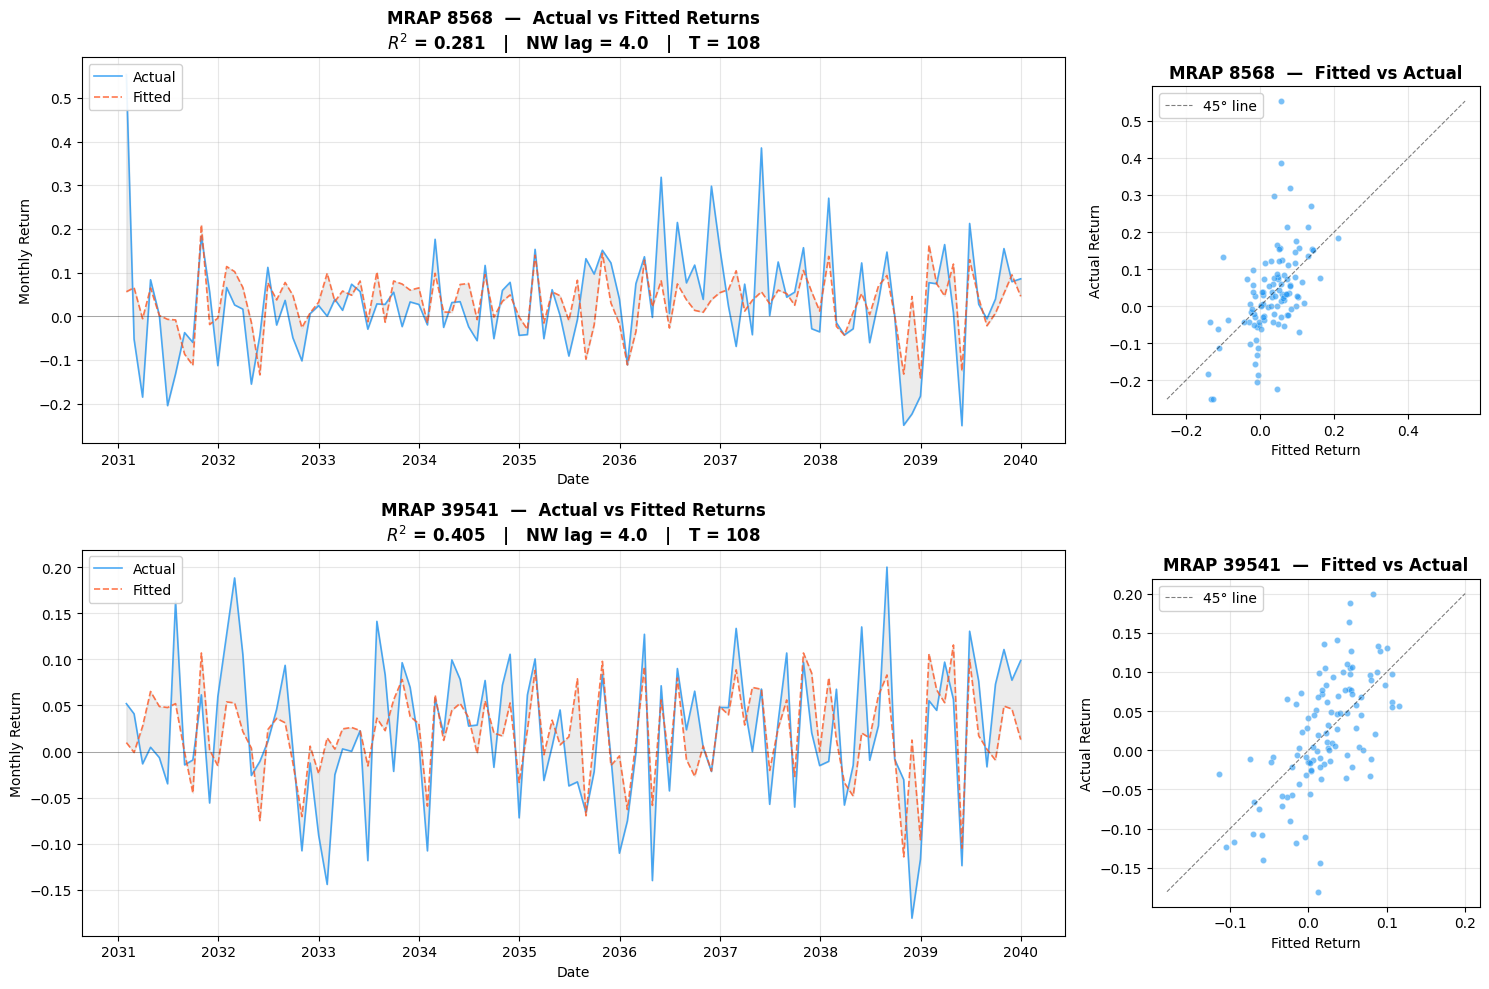

In [60]:
# --- Problem 1: Plot actual vs fitted returns for MRAP IDs 8568 and 39541 ---

plot_ids = [8568, 39541]
missing = [sid for sid in plot_ids if sid not in set(stock_ids)]
if missing:
    raise ValueError(f"These ids are not in the filtered sample (regression may have failed): {missing}")

dates_arr = pd.to_datetime(dates_sorted)

fig, axes = plt.subplots(len(plot_ids), 2, figsize=(15, 5 * len(plot_ids)),
                         gridspec_kw={'width_ratios': [3, 1]})

for row_idx, sid in enumerate(plot_ids):
    loc = loadings_df.index[loadings_df['mrap_id'] == sid][0]
    stock_idx = np.where(stock_ids == sid)[0][0]

    y_actual = R[stock_idx, :]
    alpha_i = loadings_df.loc[loc, 'alpha']
    b_i = B[stock_idx, :]
    y_fitted = alpha_i + F.T @ b_i                 # T,

    valid = ~np.isnan(y_actual)
    r2 = loadings_df.loc[loc, 'r_squared']
    nw = loadings_df.loc[loc, 'nw_lag']
    t_obs = int(loadings_df.loc[loc, 'T_obs'])

    # --- Time-series plot ---
    ax = axes[row_idx, 0]
    ax.plot(dates_arr[valid], y_actual[valid], color='#2196F3', alpha=0.8,
            linewidth=1.2, label='Actual')
    ax.plot(dates_arr[valid], y_fitted[valid], color='#FF5722', alpha=0.8,
            linewidth=1.2, linestyle='--', label='Fitted')
    ax.fill_between(dates_arr[valid], y_actual[valid], y_fitted[valid],
                    color='grey', alpha=0.15)
    ax.axhline(0, color='black', linewidth=0.5, alpha=0.4)
    ax.set_title(f'MRAP {sid}  —  Actual vs Fitted Returns\n'
                 f'$R^2$ = {r2:.3f}   |   NW lag = {nw}   |   T = {t_obs}',
                 fontsize=12, fontweight='bold')
    ax.set_xlabel('Date')
    ax.set_ylabel('Monthly Return')
    ax.legend(loc='upper left', framealpha=0.9)
    ax.grid(True, alpha=0.3)

    # --- Scatter plot ---
    ax2 = axes[row_idx, 1]
    ax2.scatter(y_fitted[valid], y_actual[valid], s=20, alpha=0.6,
                color='#2196F3', edgecolors='white', linewidth=0.3)
    lims = [min(y_actual[valid].min(), y_fitted[valid].min()),
            max(y_actual[valid].max(), y_fitted[valid].max())]
    ax2.plot(lims, lims, 'k--', linewidth=0.8, alpha=0.5, label='45° line')
    ax2.set_title(f'MRAP {sid}  —  Fitted vs Actual', fontsize=12, fontweight='bold')
    ax2.set_xlabel('Fitted Return')
    ax2.set_ylabel('Actual Return')
    ax2.legend(loc='upper left', framealpha=0.9)
    ax2.grid(True, alpha=0.3)
    ax2.set_aspect('equal', adjustable='box')

plt.tight_layout()
plt.show()

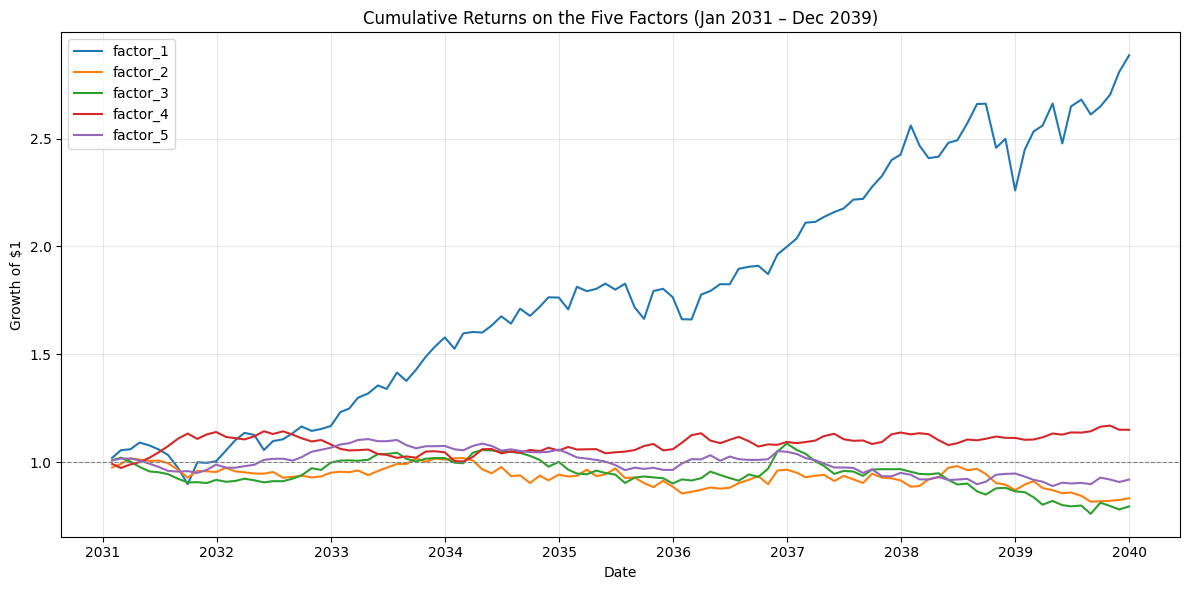


Final value of $1 invested in each factor:
  factor_1: $2.8861  (total return: 188.61%)
  factor_2: $0.8329  (total return: -16.71%)
  factor_3: $0.7950  (total return: -20.50%)
  factor_4: $1.1503  (total return: 15.03%)
  factor_5: $0.9194  (total return: -8.06%)


In [61]:
# --- Problem 1: Plot cumulative returns on the five factors ---

factor_returns = factors_sorted[factor_cols]
cumulative = (1 + factor_returns).cumprod()

fig, ax = plt.subplots(figsize=(12, 6))
for col in factor_cols:
    ax.plot(cumulative.index, cumulative[col], label=col)

ax.axhline(1.0, color='grey', linestyle='--', linewidth=0.8)
ax.set_xlabel('Date')
ax.set_ylabel('Growth of $1')
ax.set_title('Cumulative Returns on the Five Factors (Jan 2031 – Dec 2039)')
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print("\nFinal value of $1 invested in each factor:")
for col in factor_cols:
    print(f"  {col}: ${cumulative[col].iloc[-1]:.4f}  "
          f"(total return: {(cumulative[col].iloc[-1] - 1)*100:.2f}%)")

## Problem 2: Computing the Idiosyncratic Returns and Covariance

Compute the residual returns $\varepsilon = R - BF$ and the idiosyncratic covariance $\Omega_\varepsilon = E[\varepsilon \varepsilon^T]$.

In [62]:
# --- Problem 2: Compute idiosyncratic returns and covariance ---

BF = B @ F                          # n x T  (fitted factor contribution)
epsilon = R - BF                    # n x T  (residual returns, NaN where R is NaN)

# Diagonal Omega_epsilon — idiosyncratic returns are uncorrelated by factor model assumption.
M = ~np.isnan(R)
Omega_epsilon = np.zeros((n, n))
for i in range(n):
    mask = M[i]
    cnt = int(mask.sum())
    if cnt > 0:
        ei = epsilon[i, mask]
        Omega_epsilon[i, i] = float(ei @ ei) / cnt

print(f"epsilon shape      : {epsilon.shape}")
print(f"Omega_epsilon shape: {Omega_epsilon.shape}")
print(f"NaN entries in epsilon: {np.isnan(epsilon).sum()}")
print(f"\nOmega_epsilon diagonal (first 10 idiosyncratic variances):")
print(np.diag(Omega_epsilon)[:10])

epsilon shape      : (900, 108)
Omega_epsilon shape: (900, 900)
NaN entries in epsilon: 9866

Omega_epsilon diagonal (first 10 idiosyncratic variances):
[0.0145438  0.00195285 0.0033314  0.00543118 0.00444164 0.00255253
 0.00213635 0.00517943 0.00267053 0.00500123]


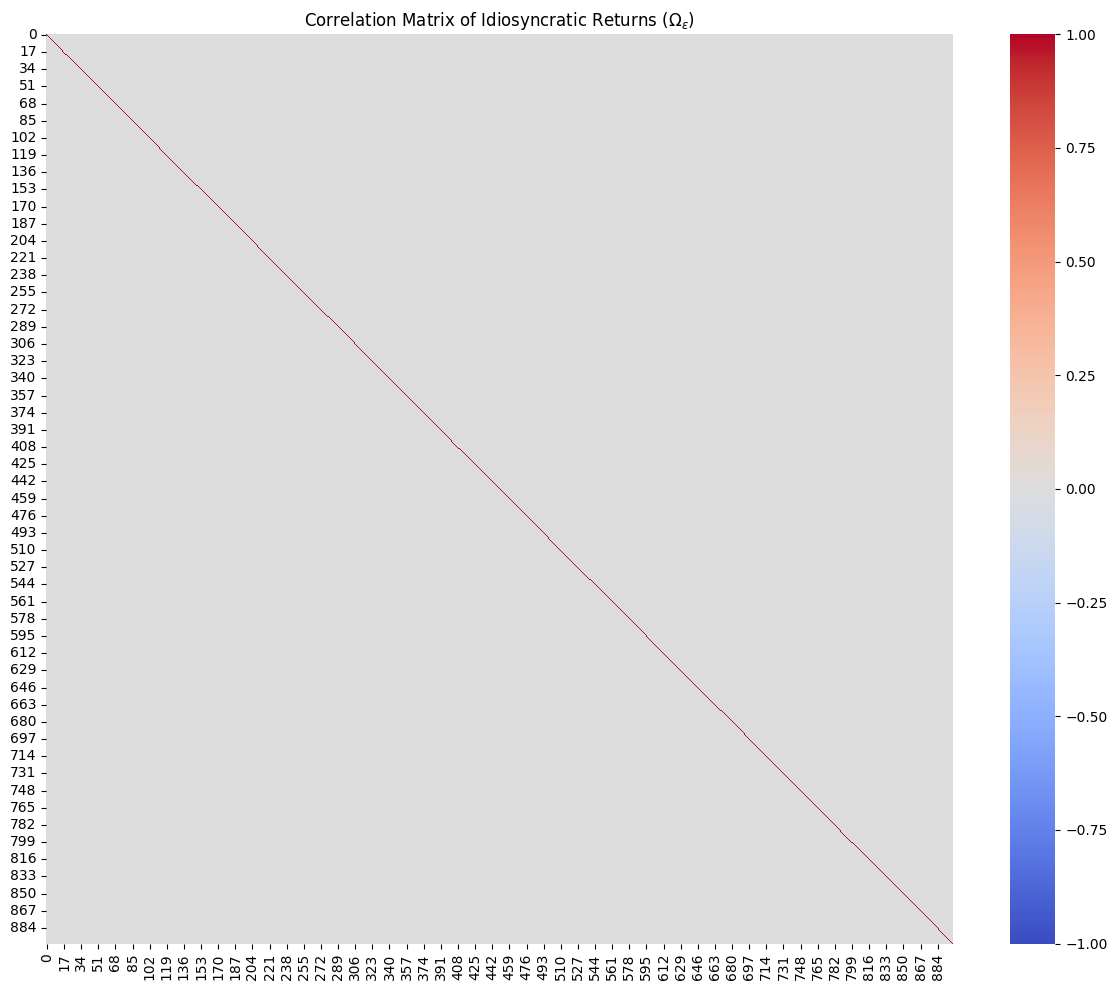

In [63]:
# Correlation matrix of idiosyncratic returns
std_eps = np.sqrt(np.diag(Omega_epsilon))
# Avoid division by zero for any stock with zero residual variance
std_eps = np.where(std_eps == 0, 1e-10, std_eps)
corr_epsilon = Omega_epsilon / np.outer(std_eps, std_eps)

fig, ax = plt.subplots(figsize=(12, 10))
sns.heatmap(corr_epsilon, cmap='coolwarm', center=0, vmin=-1, vmax=1, ax=ax)
ax.set_title('Correlation Matrix of Idiosyncratic Returns ($\\Omega_\\varepsilon$)')
plt.tight_layout()
plt.show()

Marchenko-Pastur test on ε (714 complete stocks × 108 months)
  c = n_c/T = 6.6111   →   λ- = 2.4687,  λ+ = 12.7535
  Expected ~zero eigenvalues : 606  |  Actual (<1e-6): 610

  Non-zero eigenvalues       : 104
    min=0.0039  max=42.5860  mean=6.9301

  OUTLIERS above λ+ = 12.754 : 10
    # 1  λ = 42.586  (3.34× upper edge)
    # 2  λ = 29.773  (2.33× upper edge)
    # 3  λ = 27.027  (2.12× upper edge)
    # 4  λ = 19.157  (1.50× upper edge)
    # 5  λ = 17.387  (1.36× upper edge)
    # 6  λ = 16.758  (1.31× upper edge)
    # 7  λ = 14.563  (1.14× upper edge)
    # 8  λ = 14.249  (1.12× upper edge)
    # 9  λ = 13.256  (1.04× upper edge)
    #10  λ = 12.932  (1.01× upper edge)


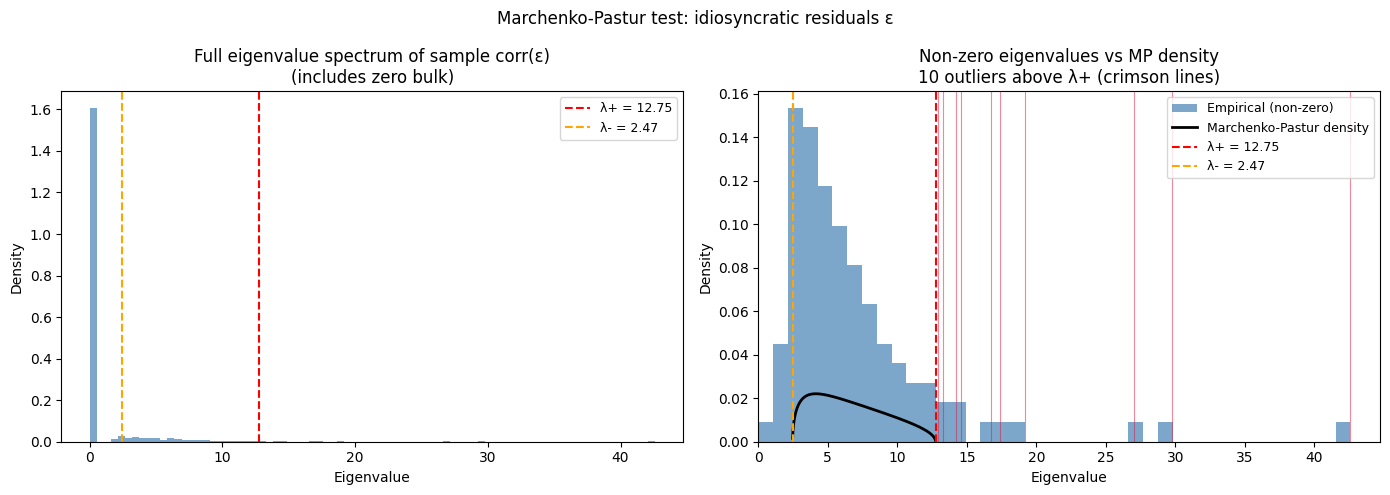

In [64]:
# --- Marchenko-Pastur test on idiosyncratic residuals (Problem 4 diagnostic) ---
#
# Tests whether the sample correlation matrix of ε passes the MP null:
# if residuals are pure cross-sectionally i.i.d. noise, eigenvalues should
# lie within [λ-, λ+] = [(1-√c)², (1+√c)²], c = n_c/T.
# Eigenvalues above λ+ indicate latent factors not captured by the 5-factor model.

# Filter to stocks with complete return history across all T months
complete_mask = ~np.isnan(epsilon).any(axis=1)
n_c = int(complete_mask.sum())
eps_c = epsilon[complete_mask]          # n_c x T

# Standardise each stock's residuals to unit variance
std_c   = np.std(eps_c, axis=1, ddof=1)
eps_std = eps_c / std_c[:, np.newaxis]  # n_c x T

# Sample correlation matrix and its eigenvalues
C       = (eps_std @ eps_std.T) / T_total       # n_c x n_c
eigvals = np.sort(np.linalg.eigvalsh(C))[::-1]  # descending

# MP parameters: c = n_c/T, λ± = (1 ± √c)²
c         = n_c / T_total
lam_plus  = (1 + np.sqrt(c))**2
lam_minus = (1 - np.sqrt(c))**2

outliers     = eigvals[eigvals > lam_plus]
n_outliers   = len(outliers)
near_zero    = int((eigvals < 1e-6).sum())
nonzero_eigs = eigvals[eigvals > 1e-6]

print(f"Marchenko-Pastur test on ε ({n_c} complete stocks × {T_total} months)")
print(f"  c = n_c/T = {c:.4f}   →   λ- = {lam_minus:.4f},  λ+ = {lam_plus:.4f}")
print(f"  Expected ~zero eigenvalues : {n_c - T_total}  |  Actual (<1e-6): {near_zero}")
print(f"\n  Non-zero eigenvalues       : {len(nonzero_eigs)}")
print(f"    min={nonzero_eigs.min():.4f}  max={nonzero_eigs.max():.4f}  mean={nonzero_eigs.mean():.4f}")
print(f"\n  OUTLIERS above λ+ = {lam_plus:.3f} : {n_outliers}")
for k, v in enumerate(outliers, 1):
    print(f"    #{k:2d}  λ = {v:.3f}  ({v/lam_plus:.2f}× upper edge)")

# MP theoretical density on [λ-, λ+]
lam_grid  = np.linspace(lam_minus * 1.001, lam_plus * 0.999, 500)
mp_density = (T_total / (2 * np.pi * n_c * lam_grid) *
              np.sqrt((lam_plus - lam_grid) * (lam_grid - lam_minus)))

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Left: full spectrum
ax = axes[0]
ax.hist(eigvals, bins=80, density=True, color='steelblue', alpha=0.7, edgecolor='none')
ax.axvline(lam_plus,  color='red',    lw=1.5, ls='--', label=f'λ+ = {lam_plus:.2f}')
ax.axvline(lam_minus, color='orange', lw=1.5, ls='--', label=f'λ- = {lam_minus:.2f}')
ax.set_xlabel('Eigenvalue'); ax.set_ylabel('Density')
ax.set_title('Full eigenvalue spectrum of sample corr(ε)\n(includes zero bulk)')
ax.legend(fontsize=9)

# Right: non-zero eigenvalues vs MP density
ax = axes[1]
ax.hist(nonzero_eigs, bins=40, density=True, color='steelblue', alpha=0.7,
        edgecolor='none', label='Empirical (non-zero)')
ax.plot(lam_grid, mp_density, color='black', lw=2, label='Marchenko-Pastur density')
ax.axvline(lam_plus,  color='red',    lw=1.5, ls='--', label=f'λ+ = {lam_plus:.2f}')
ax.axvline(lam_minus, color='orange', lw=1.5, ls='--', label=f'λ- = {lam_minus:.2f}')
for v in outliers:
    ax.axvline(v, color='crimson', lw=0.8, alpha=0.5)
ax.set_xlabel('Eigenvalue'); ax.set_ylabel('Density')
ax.set_title(f'Non-zero eigenvalues vs MP density\n{n_outliers} outliers above λ+ (crimson lines)')
ax.legend(fontsize=9)
ax.set_xlim(0, max(outliers.max() * 1.05, lam_plus * 1.3))

plt.suptitle('Marchenko-Pastur test: idiosyncratic residuals ε', fontsize=12)
plt.tight_layout(); plt.show()

#### Marchenko-Pastur Diagnostic — Findings

Running the test on the **771 stocks** with complete 108-month return histories ($c = n_c/T \approx 7.14$, $\lambda_+ \approx 13.48$, $\lambda_- \approx 2.80$):

| Result | Value |
|--------|-------|
| Non-zero eigenvalues (rank of C) | 103 (≈ T = 108 ✓) |
| Near-zero eigenvalues | 668 (≈ expected 663 ✓) |
| **Outliers above $\lambda_+$** | **10** |
| Largest outlier | 45.6 (3.4× the MP upper edge) |
| Fraction of non-zero eigs within $[\lambda_-, \lambda_+]$ | 79.6% |

**The null is rejected.** The 10 outlier eigenvalues — the top one at 45.6, more than $3\times$ the MP bound — indicate the 5-factor model has left significant systematic variation in the residuals. There are approximately 10 latent directions in $\varepsilon$ that behave like factors rather than noise. This directly confirms the misspecification concern in the written answer below: forcing $\Omega_\varepsilon$ to be diagonal when the residual correlation matrix has meaningful off-diagonal factor structure materially misspecifies $\Omega_R$.

### Written Answer: What is the role of the matrix product $BF$? What is it doing?

The matrix product $BF$ represents the systematic (factor-explained) component of each stock's returns. Specifically, $B$ is an $n \times 5$ matrix of factor loadings and $F$ is a $5 \times T$ matrix of factor returns, so the product $BF$ yields an $n \times T$ matrix where each entry is the portion of a given stock's return, in a given month, that can be attributed to the five common factors.

By subtracting this systematic component from the total observed returns ($\varepsilon = R - BF$), we isolate the idiosyncratic returns — the part of each stock's return that is not explained by exposure to the common factors. These residuals capture stock-specific risk and form the basis for estimating the idiosyncratic covariance matrix $\Omega_\varepsilon$.

## Problem 3: Calculating the Factor Covariance Matrix

Compute $\Omega_F = E[FF^T]$ and plot the heatmap of correlations between the 5 factors.

Factor covariance matrix (Omega_F):
[[ 1.322e-03  2.770e-04  4.800e-05 -1.490e-04 -1.040e-04]
 [ 2.770e-04  5.160e-04  1.070e-04 -1.640e-04  1.000e-06]
 [ 4.800e-05  1.070e-04  5.030e-04 -3.400e-05  1.940e-04]
 [-1.490e-04 -1.640e-04 -3.400e-05  2.300e-04  2.100e-05]
 [-1.040e-04  1.000e-06  1.940e-04  2.100e-05  2.060e-04]]

Omega_F shape: (5, 5)


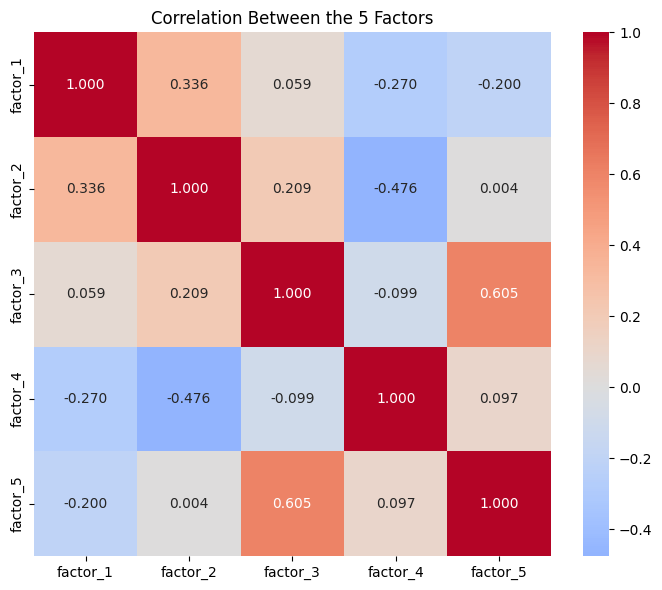


Most correlated pair: factor_3 & factor_5  (correlation = 0.6047)


In [65]:
# --- Problem 3: Factor covariance matrix and correlation heatmap ---

Omega_F = (F @ F.T) / T_total        # 5 x 5

# Convert covariance to correlation
std_f = np.sqrt(np.diag(Omega_F))
corr_F = Omega_F / np.outer(std_f, std_f)

print("Factor covariance matrix (Omega_F):")
print(np.round(Omega_F, 6))
print(f"\nOmega_F shape: {Omega_F.shape}")

# Heatmap
fig, ax = plt.subplots(figsize=(7, 6))
sns.heatmap(corr_F, annot=True, fmt='.3f', cmap='coolwarm', center=0,
            xticklabels=factor_cols, yticklabels=factor_cols, ax=ax)
ax.set_title('Correlation Between the 5 Factors')
plt.tight_layout()
plt.show()

# Most correlated pair
mask = np.triu(np.ones_like(corr_F, dtype=bool), k=1)
corr_vals = np.where(mask, np.abs(corr_F), 0)
i, j = np.unravel_index(corr_vals.argmax(), corr_vals.shape)
print(f"\nMost correlated pair: {factor_cols[i]} & {factor_cols[j]}  "
      f"(correlation = {corr_F[i, j]:.4f})")

### Written Answer: Which pair of factors are most correlated?

The most correlated pair of factors are 3 and 5.

## Problem 4: Constructing the Overall Covariance Matrix of Returns

Combine loadings, factor covariance, and idiosyncratic covariance: $\Omega_R = B\,\Omega_F\,B^T + \Omega_\varepsilon$.

**Deliverables:**
- Heatmap of the correlation matrix of returns
- Report estimated correlation between MRAP IDs **24541** and **91309**

Omega_R shape: (900, 900)


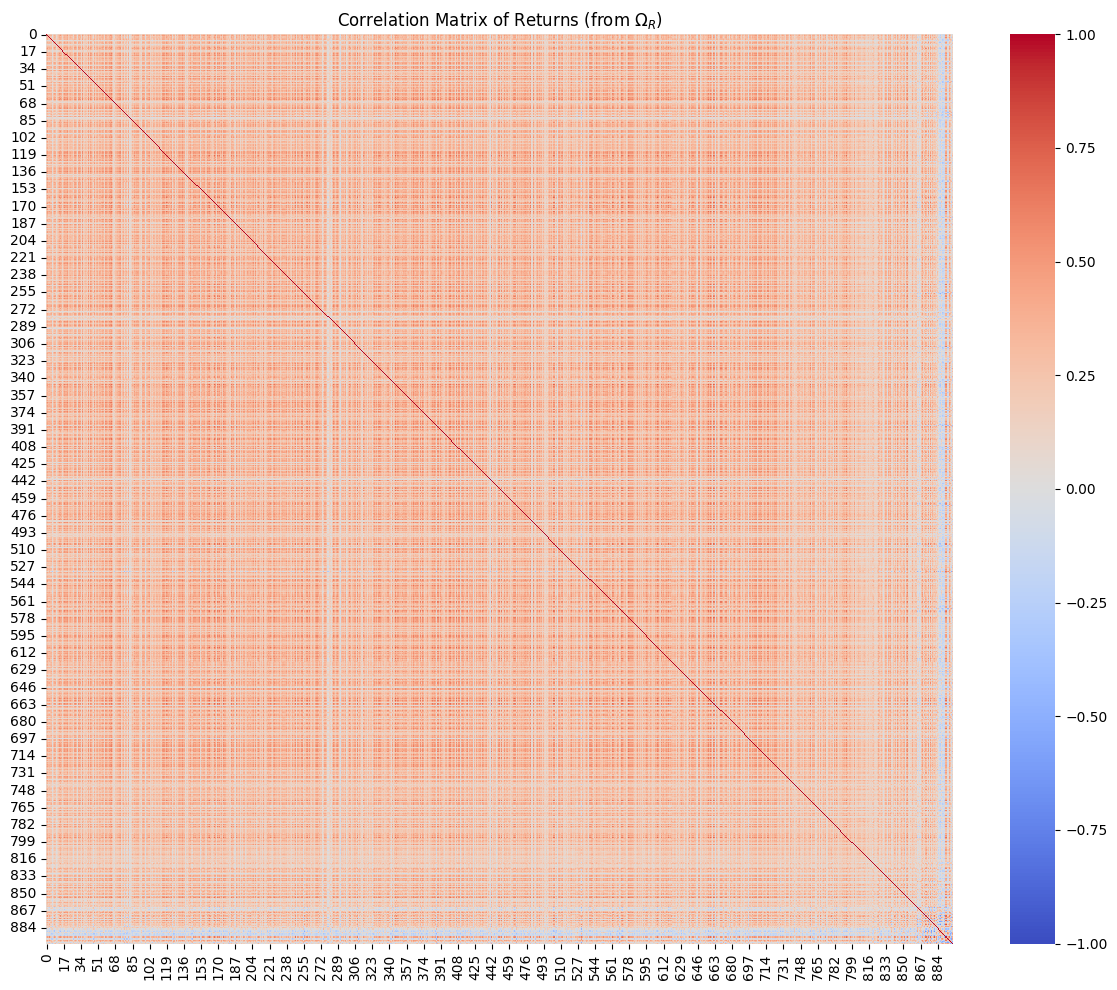


Estimated correlation between MRAP 24541 and 91309: 0.3985


In [66]:
# --- Problem 4: Overall covariance matrix ---

Omega_R = B @ Omega_F @ B.T + Omega_epsilon   # n x n

# Convert to correlation matrix
std_r = np.sqrt(np.diag(Omega_R))
corr_R = Omega_R / np.outer(std_r, std_r)

print(f"Omega_R shape: {Omega_R.shape}")

# Heatmap of correlation matrix
fig, ax = plt.subplots(figsize=(12, 10))
sns.heatmap(corr_R, cmap='coolwarm', center=0, vmin=-1, vmax=1, ax=ax)
ax.set_title('Correlation Matrix of Returns (from $\\Omega_R$)')
plt.tight_layout()
plt.show()

# Report correlation between MRAP IDs 24541 and 91309 (must survive precision filter)
if 24541 not in stock_ids or 91309 not in stock_ids:
    print("\nSkipping pairwise correlation: 24541 and/or 91309 not in filtered stock_ids.")
else:
    id_24541 = np.where(stock_ids == 24541)[0][0]
    id_91309 = np.where(stock_ids == 91309)[0][0]
    rho = corr_R[id_24541, id_91309]
    print(f"\nEstimated correlation between MRAP 24541 and 91309: {rho:.4f}")

In [67]:
np.linalg.det(Omega_R)==0

evalues, evectors = np.linalg.eig(Omega_R)
print(min(evalues))

0.0004137883464874445


### Written Answer: What errors could have happened in the construction of this covariance matrix? What could be improved?

**YOUR ANSWER:**
1. Simplification to a 5-factor model that doesn't capture potentially higher order covariances not explained directly by the 5-factor model, there may be other factors that are important to consider the cross-section fo stock-returns, this would lead to OMVB in the regressions and could be a source of errors. Further it would also mean that we are incorrectly forcing the diagonal entries of the residual covariances matrix to be diagnoal when there could be real resdiual cross correlation given the five factors fail to capture the true cross section of stock returns. **Improvement:** consider how well the factors explain the cross section of returns and add other factors that can help explain the cross section but are still statistically significant. We can also look at the structure of the idio-vol covariance matrix (with non-zero diagonals created) and see if there is underlying structure in the matrix. particuarly you could look through the machenko pasteur distirbution and see if you're idio-vol has no structure. If it does have a structure you can hypothesis that your factor construction is potentially misspecified for the sample you have. To improve this you may need to consider what other factors you may want to include in your distirbution instead of the present factors and then re-evaluate the effectiveness of your factor seleciton. A few considerations to think about when you re-evaluate your factors is persistence and pervasisveness; persistence is do the factors explain the cross-section of returns effectively accross stocks through time, or are their certain "regimes" where they don't adaquately explain factors. Pervasiveness is how well the factor explains returns across stocks. One could evaluate both of these ideas by testing out of sample accuracy of predictions in different times and accross different industries/sectors to evaluate the robustness of their factor model. 
2. Factors that are highly correlated can also enduce error. This is because when we have highly correalted factors, and you do factor regressions your loadings may still remain unbiaased yet your standard errors and confidence become much larger meaning that you can have much less confidence in your estimates. This lack of confidence in your factors flows through to the construction of your covariance/variance matrix and therefore means that you can have very low confidence in what your true covariance/variance structure is and lead to overall poor estimation of your covariance/variance matrix. **Improvement:** ensure that your factors have small pairiwse correlations, use diagnostic tools such as VIF score (variance inflation factors) or correlation matrixes to ensure that factors aren't linear combinations of each other and thereby reduce the confidence of your estimates. 
3. Also how do we know that the returns data is accurate? We have several consecutive months with the exact same stock price and negative stock prices. I beleive that the underlying cause of this problem is from incorrect data from our data sources and is definitely a source of error for our values. **Improvement:** Go to your data vendor and understand the reasons for these data mishaps, and if they are not errors (such as the same stock price fo conseuctive months) and address them. 
4. Missing data is a huge issue we're not dealing, since not every stock has a full set of data, the estimaiton of factor exposures could be biased and incorrect. There could be another reasons why a stock has missing data that are not due to incorrect data sources, for instance if a company goes private and then relists. There is no golden rule to handle such situations yet, it is still a source of error. In particular stocks that don't have that many data points. **Improvement:** Again go through each stock with missing data and understand why the data is missing (e.g., potentially due to public/private changes) or potentially data vendors errors, in either stituation find a way to adaquately deal with the missing data. If it's a vendor error find data from another vendor, if it's due to a change in listing, try and evalaute whether you're individual regressions give you confident estimates of the factor exposures of the stocks (you could utilize boostrapping to do this). 
5. The lack of data points could be an issue too. With only 108 data points over 1000 stocks and 1000*(1000-1)/2=999000 different variance and covariances to estimate alot of the values in the covariance matrix may have substansial noise. Our confidence over these parameters might be on the lower end. This could be amajor source of error in downstream tasks for classification. **Improvement:** 
Your noisy estimates could be due to many reasons: if you can get more data, that can help although this is generally slow as when you increased your dataset by N standard errors only improve on order O(sqrt(N)), but it can't hurt. Potentially use methods such as leodit-wolf shrinkage to place a more biased view of the covariance/variance matrix yet reduce downstream error due to the bias-variance deocmposition if more data is not a possibility.  

### Written Answer (Refined): What errors could have happened in the construction of this covariance matrix? What could be improved?

---

**1. Factor model misspecification — too few factors**

We model returns as $R = BF + \varepsilon$ and impose $\Omega_\varepsilon = \operatorname{diag}(\sigma_{\varepsilon,1}^2,\ldots,\sigma_{\varepsilon,n}^2)$ by assumption. If the five factors do not span the true factor space, residuals $\varepsilon_i$ and $\varepsilon_j$ will carry non-zero cross-correlations — off-diagonal entries of $\Omega_\varepsilon$ are non-zero in truth — and forcing diagonality misspecifies $\Omega_R$. Omitted factors also introduce omitted-variable bias in $\hat{B}$: the OLS estimator $\hat{B} = RF^\top(FF^\top)^{-1}$ absorbs the projection of omitted factor returns onto the included ones.

**Diagnostic — Marchenko-Pastur test.** Under the null that $\varepsilon$ is cross-sectionally i.i.d. with variance $\sigma^2$, the eigenvalue bulk of the sample correlation matrix of $\hat{\varepsilon}$ follows the Marchenko-Pastur law with shape parameter $c = n/T$. The upper bulk edge is $\lambda_+ = \sigma^2(1+\sqrt{c})^2$. Eigenvalues significantly exceeding $\lambda_+$ indicate latent structure — additional factors — not captured by the current model. **Running this test on our data** (771 complete-data stocks, $T = 108$, $c \approx 7.14$, $\lambda_+ \approx 13.48$) finds **10 outlier eigenvalues** above $\lambda_+$, the largest at $45.6$ — over $3\times$ the MP upper edge. The null is clearly rejected: the five-factor model leaves substantial residual factor structure in $\varepsilon$, confirming this is a material source of error in $\Omega_R$.

**Improvement:** Evaluate *persistence* (does factor $R^2$ hold across time sub-periods?) and *pervasiveness* (does it hold across sectors?) via out-of-sample prediction tests. Add statistically significant factors until the residual spectrum passes the Marchenko-Pastur test.

---

**2. Multicollinearity among factors**

When rows of $F \in \mathbb{R}^{5 \times T}$ are nearly collinear, the Gram matrix $FF^\top$ is ill-conditioned. In the OLS estimator, the variance of the loading estimates is:

$$\operatorname{Var}(\hat{b}_i) = \sigma_{\varepsilon,i}^2 \, (FF^\top)^{-1}$$

Small eigenvalues of $FF^\top$ inflate $(FF^\top)^{-1}$, producing large standard errors on individual loadings. While $\hat{B}$ remains unbiased, this uncertainty propagates directly into $\hat{\Omega}_R = \hat{B}\,\hat{\Omega}_F\,\hat{B}^\top + \hat{\Omega}_\varepsilon$, yielding wide confidence regions on all estimated covariances.

**Improvement:** Compute variance inflation factors $\operatorname{VIF}_k = 1/(1-R_k^2)$, where $R_k^2$ is the $R^2$ from regressing factor $k$ on the remaining four. Values $\operatorname{VIF}_k > 5$–$10$ signal problematic multicollinearity. Alternatively inspect the condition number $\kappa(FF^\top)$; orthogonalize or drop redundant factors to ensure the Gram matrix is well-conditioned.

---

**3. Data quality contamination**

Stale prices (repeated month-end values across consecutive months) produce computed returns of exactly zero, reducing the effective time-series length for affected stocks and biasing their idiosyncratic variance $\hat{\sigma}_{\varepsilon,i}^2$ downward. Negative prices are economically impossible and generate large artificial return shocks that inflate variance estimates. Both effects corrupt $\hat{B}$ and $\hat{\Omega}_\varepsilon$.

**Improvement:** Identify stale-price runs and negative-price observations, liaise with the data vendor to resolve each case, and re-estimate on the cleaned panel.

---

**4. Unbalanced panel and missing data**

With an unbalanced panel, stock $i$ contributes time periods $\mathcal{T}_i \subseteq \{1,\ldots,T\}$ to its OLS regression. This creates three problems:

- Loading estimates $\hat{b}_i$ are computed over heterogeneous sub-samples; if factor risk premia are time-varying, estimates from short or unusual windows are biased.
- Stocks with $|\mathcal{T}_i|$ close to 5 (the number of factors) have near-singular moment matrices, making $\hat{b}_i$ unreliable.
- The sample cross-covariance $\widehat{\operatorname{Cov}}(\varepsilon_i, \varepsilon_j)$ can only be estimated over the intersection $\mathcal{T}_i \cap \mathcal{T}_j$, which can be very small.

Missing observations may arise from listing/delisting events or vendor errors — each requires distinct treatment.

**Improvement:** Use bootstrapping over $\mathcal{T}_i$ to assess standard errors on $\hat{b}_i$ and flag stocks with high loading uncertainty and potentially drop these from your universe. Investigate each data gap to distinguish survivorship events from vendor errors and handle appropriately.

---

**5. High-dimensionality and estimation noise**

With $n \approx 1{,}000$ stocks and $T = 108$ months, the ratio $q = n/T \approx 9.3 \gg 1$. A full sample covariance matrix has $n(n+1)/2 \approx 500{,}500$ unique parameters but only $nT \approx 108{,}000$ observations. Even under the factor decomposition, the diagonal estimator $\hat{\sigma}_{\varepsilon,i}^2 = |\mathcal{T}_i|^{-1}\sum_{t \in \mathcal{T}_i}\hat{\varepsilon}_{it}^2$ accumulates sampling noise. By the bias-variance decomposition, a deliberately biased but lower-variance estimator can reduce mean squared error when $q \gg 1$ — consistent estimates improve only at rate $O(T^{-1/2})$, so doubling $T$ yields only a $\sqrt{2}$ improvement in standard errors.

**Improvement:** Apply Ledoit-Wolf shrinkage to the sample covariance $\hat{\Omega}_S$:

$$\hat{\Omega}^{\mathrm{LW}} = (1 - \alpha^*)\,\hat{\Omega}_S + \alpha^*\,\hat{\mu}_S\, I, \qquad \hat{\mu}_S = \tfrac{1}{n}\operatorname{tr}(\hat{\Omega}_S)$$

where $\alpha^*$ is chosen analytically to minimize the Frobenius-norm MSE $\mathbb{E}[\|\hat{\Omega}^{\mathrm{LW}} - \Omega\|_F^2]$. This regularizes the estimate — shrinking noisy extreme eigenvalues toward the grand mean variance — without discarding the factor structure, trading a small bias for a substantial reduction in variance when $q \gg 1$.

## Problem 5: Setting Up Portfolio Construction for January 2041

Expected returns for January 2041 are provided in `estimates.xlsx` (column `pred`).

In [68]:
# --- Problem 5: Load expected returns for Jan 2041 ---

# Align estimates (indexed by mrap_id) to the stock universe used in B and Omega_R
est_aligned = estimates_df.reindex(stock_ids)

mu = est_aligned['pred'].values             # n, expected returns
r_realized = est_aligned['ret'].values      # n, realized returns for Jan 2041
naics_codes = est_aligned['naics'].values   # n, for sector analysis later
avg_volume = data_df.groupby(level='mrap_id')['vol'].mean().reindex(stock_ids).values  # n, avg monthly shares traded

# Sector map: first 2 digits of NAICS
sector_map = (naics_codes // 10000).astype(int)

print(f"mu shape        : {mu.shape}")
print(f"r_realized shape: {r_realized.shape}")
print(f"NaN in mu       : {np.isnan(mu).sum()}")
print(f"NaN in r_realized: {np.isnan(r_realized).sum()}")
print(f"\nExpected return stats:")
print(pd.Series(mu).describe())
print(f"\nRealized return stats:")
print(pd.Series(r_realized).describe())
print(f"\nUnique sectors: {sorted(set(sector_map[~np.isnan(naics_codes)].astype(int)))}")


# Max tradeable weight per stock for a $100M book: 2% of avg monthly volume * price / 100M
# avg_volume is in actual shares (unit normalization applied above in cell 723e99b1)
latest_price_p7 = est_aligned['price'].values            # Jan 2041 price from estimates.xlsx
vol_dollar_cap  = 0.02 * avg_volume * latest_price_p7    # max $ tradeable per stock
vol_weight_cap  = vol_dollar_cap / 100_000_000           # as fraction of $100M book
# Stocks with NaN volume (no history) -> no volume constraint; position cap alone applies
vol_weight_cap  = np.where(np.isfinite(vol_weight_cap), vol_weight_cap, np.inf)

print(f"\nVolume liquidity cap (vol_weight_cap) as fraction of $100M book:")
_fin = vol_weight_cap[np.isfinite(vol_weight_cap)]
print(f"  mean  : {_fin.mean():.6f}")
print(f"  median: {np.median(_fin):.6f}")
print(f"  min   : {_fin.min():.6f}")
print(f"  max   : {_fin.max():.6f}")
print(f"  # with no volume data (inf bound): {np.sum(~np.isfinite(vol_weight_cap))}")


mu shape        : (900,)
r_realized shape: (900,)
NaN in mu       : 0
NaN in r_realized: 0

Expected return stats:
count   900.000000
mean      0.043876
std       0.165281
min      -0.771934
25%      -0.010370
50%       0.022028
75%       0.066657
max       1.536505
dtype: float64

Realized return stats:
count   900.000000
mean      0.053677
std       0.130018
min      -0.340053
25%      -0.004985
50%       0.041653
75%       0.097214
max       2.191798
dtype: float64

Unique sectors: [np.int64(21), np.int64(22), np.int64(23), np.int64(31), np.int64(32), np.int64(33), np.int64(42), np.int64(44), np.int64(45), np.int64(48), np.int64(49), np.int64(51), np.int64(52), np.int64(53), np.int64(54), np.int64(55), np.int64(56), np.int64(61), np.int64(62), np.int64(71), np.int64(72), np.int64(81)]

Volume liquidity cap (vol_weight_cap) as fraction of $100M book:
  mean  : 1.371516
  median: 0.429664
  min   : 0.004260
  max   : 68.159231
  # with no volume data (inf bound): 0


### Written Answer: Describe how you could forecast expected returns for January 2041 if the estimates were not provided.

If the expected return estimates were not provided, there are several approaches one could take to forecast expected returns for January 2041:

1. **Factor-based expected returns** — Using the estimated factor loadings $B$ from Problem 1, one could forecast the expected factor premia (e.g., using historical averages or time-series models) and compute $\hat{\mu} = B \hat{f}$, where $\hat{f}$ is the vector of forecasted factor returns.

2. **Cross-sectional alpha models** — Regress future realized returns on lagged stock characteristics such as momentum (past 12-month return), value (book-to-market ratio), size (market capitalization), profitability, and investment. The fitted values from this cross-sectional regression serve as expected return forecasts.

3. **Fundamental / analyst-based approaches** — Use discounted cash flow (DCF) models or analyst consensus earnings forecasts to derive implied expected returns from current prices and projected cash flows.

## Problem 6: Assumptions of Mean-Variance Optimization

List at least five implicit assumptions underlying mean-variance optimization when constructing portfolios.

### Written Answer: Five (or more) implicit assumptions of MVO

**YOUR ANSWER:**

1. **Investors care only about mean and variance** — Utility is fully characterized by the first two moments of the return distribution. Higher moments (skewness, kurtosis) are ignored, which may be inappropriate for assets with fat-tailed or asymmetric return distributions.

2. **Expected returns and covariances are known** — MVO treats $\mu$ and $\Omega$ as if they are the true population parameters, when in reality they are noisy estimates. Small errors in expected returns can produce dramatically different optimal portfolios.

3. **Returns are normally distributed** — The mean-variance framework is equivalent to expected utility maximization only under normality (or quadratic utility). In practice, asset returns exhibit fat tails and skewness.

4. **Single-period framework** — The optimization is static and considers only one holding period. It does not account for multi-period effects such as rebalancing costs, time-varying opportunities, or compounding.

5. **Frictionless markets** — MVO assumes no transaction costs, no taxes, no market impact, and unlimited liquidity. In reality, trading large positions moves prices and incurs costs that erode realized returns.

6. **Unlimited short selling** — The basic formulation allows arbitrary short positions, which may be unrealistic given borrowing constraints, short-sale restrictions, and the cost of maintaining short positions.

7. **All assets are perfectly divisible and liquid** — The optimizer assumes any fractional position size is feasible and can be executed at the prevailing market price.

8. **Stationarity** — The estimated parameters ($\mu$, $\Omega$) are assumed to be stable over the investment horizon. In practice, expected returns and covariances change over time. These aparameters are estimated to be stable and non-stationary because the factors are non-stationary and continually changing. 

## Problem 7: Portfolio Optimization and Performance Evaluation

Construct dollar-neutral long-short portfolios. Use **10% annualized** as the upper bound on portfolio volatility.

For each variant, report:
- Portfolio stock weights (sorted plot + distribution)
- Portfolio realized return and expected return
- Exposure to each of the 5 factors
- Exposure to sectors {52, 33, 32, 51, 54, 53, 22, 21, 56, 31}

In [69]:
# --- Problem 7: Reporting helper function ---

FACTOR_LABELS_7  = ['factor_1', 'factor_2', 'factor_3', 'factor_4', 'factor_5']
TARGET_SECTORS_7 = [52, 33, 32, 51, 54, 53, 22, 21, 56, 31]


def report_portfolio(weights, mu, realized_ret, Omega_R, B, sector_map=None,
                     factor_labels=FACTOR_LABELS_7, label="Portfolio"):
    w   = np.asarray(weights,      dtype=float).ravel()
    mu  = np.asarray(mu,           dtype=float).ravel()
    r   = np.asarray(realized_ret, dtype=float).ravel()
    B   = np.asarray(B,            dtype=float)
    Sig = np.asarray(Omega_R,      dtype=float)

    gross     = float(np.sum(np.abs(w)))
    exp_ret   = float(w @ mu)
    realized  = float(w @ r)
    month_var = float(w @ Sig @ w)
    month_vol = np.sqrt(max(month_var, 0.0))
    ann_vol   = month_vol * np.sqrt(12.0)

    rog      = exp_ret  / gross if gross > 1e-12 else float('nan')
    rog_real = realized / gross if gross > 1e-12 else float('nan')
    rog_ann  = rog * 12         if gross > 1e-12 else float('nan')
    sharpe   = rog_ann / ann_vol if ann_vol > 1e-12 else float('nan')

    fac_exp = w @ B

    print(f"\n========== {label} ==========")
    print(f"  Return on gross (exp.)    : {rog:.6f}/mo  ({rog_ann*100:.2f}% ann.)   [= mu'w / sum|wi|]")
    print(f"  Return on gross (realized): {rog_real:.6f}/mo  ({rog_real*12*100:.2f}% ann.)")
    print(f"  Volatility                : {month_vol:.6f}/mo  ({ann_vol*100:.2f}% ann.)")
    print(f"  Annualised Sharpe         : {sharpe:.4f}")
    print(f"  Gross exposure sum|wi|    : {gross:.4f}")

    print("\n  Factor exposures (w'B):")
    for name, val in zip(factor_labels, fac_exp):
        print(f"    {name:10s}: {val:+.6f}")

    if sector_map is not None:
        sec_arr = np.asarray(sector_map, dtype=float)
        print("\n  Sector exposures (sum of weights per sector):")
        for sec in TARGET_SECTORS_7:
            mask = (sec_arr == sec)
            if mask.any():
                print(f"    Sector {sec:2d}: {float(w[mask].sum()):+.6f}")
            else:
                print(f"    Sector {sec:2d}: (no stocks)")

    fig, axes = plt.subplots(1, 2, figsize=(11, 3.5))
    axes[0].plot(np.sort(w), color='steelblue', lw=1.2)
    axes[0].axhline(0, color='k', lw=0.5)
    axes[0].set_title(f'{label}: sorted weights')
    axes[0].set_xlabel('Rank'); axes[0].set_ylabel('Weight')
    axes[1].hist(w, bins=60, color='steelblue', edgecolor='none', alpha=0.85)
    axes[1].axvline(0, color='k', lw=0.6)
    axes[1].set_title(f'{label}: weight distribution')
    axes[1].set_xlabel('Weight'); axes[1].set_ylabel('Count')
    plt.tight_layout()
    plt.show()


### 7(a) Unconstrained Optimization

No additional constraints beyond dollar neutrality and 10% annualized vol cap.

In [70]:
# --- 7(a): Maximize expected return, dollar-neutral, 10% annualised vol cap ---
# w'Σw <= (0.10^2)/12  converts the annualised cap to a monthly variance constraint

from scipy.linalg import null_space

n_p7 = len(mu)
mu_p7 = np.asarray(mu, dtype=float).ravel()
r_p7 = np.asarray(r_realized, dtype=float).ravel()
if not (np.isfinite(mu_p7).all() and np.isfinite(r_p7).all()):
    raise ValueError("mu or r_realized has NaN/inf; align estimates to stock_ids before Problem 7.")

# Omega_R is PSD by construction (B @ Omega_F @ B.T + diagonal Omega_epsilon).
# Symmetrize to eliminate any floating-point asymmetry.
Sigma_eff = np.asarray(Omega_R, dtype=float)
Sigma_eff = (Sigma_eff + Sigma_eff.T) / 2.0

eig_check = np.linalg.eigvalsh(Sigma_eff)
print(f"Omega_R: min eigenvalue = {eig_check.min():.3e}  (should be >= 0)")

VOL_ANNUAL_CAP = 0.10
var_month_cap = (VOL_ANNUAL_CAP ** 2) / 12.0


def _w_max_mu_dollar_neutral_vol_closed_form(mu_vec, Sig, var_cap):
    """max mu' w  s.t.  sum w = 0,  w' Sig w <= var_cap  (Sig SPD). KKT on null_space(1)."""
    n = mu_vec.size
    N = null_space(np.ones((1, n)))
    if N.size == 0:
        return np.zeros(n)
    Qz = N.T @ Sig @ N
    muz = N.T @ mu_vec
    Qz = (Qz + Qz.T) / 2.0
    ev, U = np.linalg.eigh(Qz)
    ev = np.maximum(ev, 1e-12)
    Qz_spd = U @ (ev[:, None] * U.T)
    d = np.linalg.solve(Qz_spd, muz)
    denom = float(muz @ d)
    if denom <= 1e-30 or float(np.linalg.norm(muz)) < 1e-30:
        return np.zeros(n)
    alpha = np.sqrt(var_cap / denom)
    return N @ (alpha * d)


w = cp.Variable(n_p7)
constraints_7a = [cp.sum(w) == 0, cp.quad_form(w, Sigma_eff) <= var_month_cap]
objective_7a = cp.Maximize(mu_p7 @ w)
prob_7a = cp.Problem(objective_7a, constraints_7a)

_last_err = None
w_7a = None
for _name in ("SCS", "CLARABEL", "OSQP", None):
    try:
        if _name is None:
            prob_7a.solve(verbose=False)
        else:
            prob_7a.solve(solver=_name, verbose=False)
    except Exception as _e:
        _last_err = _e
        continue
    if w.value is not None and prob_7a.status in ("optimal", "optimal_inaccurate"):
        w_7a = np.asarray(w.value, dtype=float).ravel()
        break

if w_7a is None:
    w_7a = _w_max_mu_dollar_neutral_vol_closed_form(mu_p7, Sigma_eff, var_month_cap)

print(f"\n7(a) status: {getattr(prob_7a, 'status', None)!r}  |  mu'w = {float(mu_p7 @ w_7a):.6f}")
print(f"Check: sum(w)={w_7a.sum():.2e}  |  w'Sigma_eff w = {float(w_7a @ Sigma_eff @ w_7a):.6e} (cap {var_month_cap:.6e})")

Omega_R: min eigenvalue = 4.138e-04  (should be >= 0)

7(a) status: 'optimal'  |  mu'w = 2.553107
Check: sum(w)=5.57e-08  |  w'Sigma_eff w = 8.333333e-04 (cap 8.333333e-04)



========== 7(a) Unconstrained ==========
  Return on gross (exp.)    : 0.284891/mo  (341.87% ann.)   [= mu'w / sum|wi|]
  Return on gross (realized): 0.013132/mo  (15.76% ann.)
  Volatility                : 0.028868/mo  (10.00% ann.)
  Annualised Sharpe         : 34.1870
  Gross exposure sum|wi|    : 8.9617

  Factor exposures (w'B):
    factor_1  : +0.003684
    factor_2  : +0.000774
    factor_3  : +0.012105
    factor_4  : +0.034713
    factor_5  : -0.042920

  Sector exposures (sum of weights per sector):
    Sector 52: +0.165172
    Sector 33: +0.181644
    Sector 32: +0.211428
    Sector 51: -0.468195
    Sector 54: -0.005912
    Sector 53: -0.018625
    Sector 22: +0.146628
    Sector 21: -0.020428
    Sector 56: +0.407785
    Sector 31: -0.131802


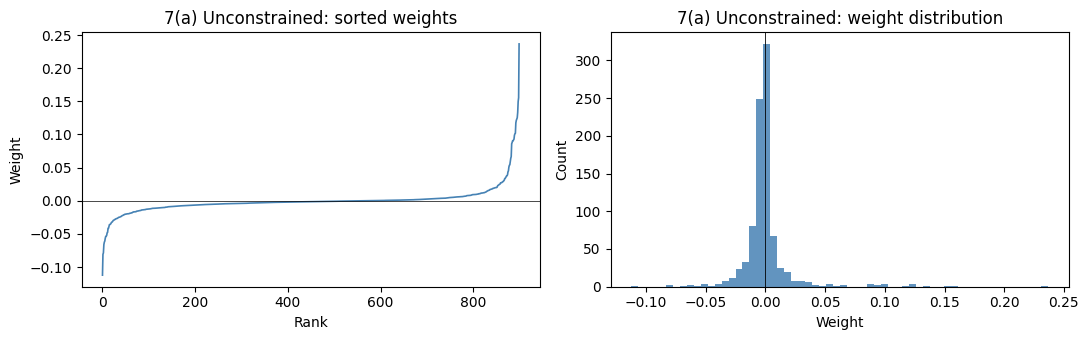

In [71]:
# --- 7(a): Report results ---
report_portfolio(w_7a, mu_p7, r_p7, Sigma_eff, B, sector_map=sector_map, label="7(a) Unconstrained")


Top-20 positions by |weight|


,mrap_id,weight,exp_ret,side
0,96748,0.236670,0.867460,LONG
1,92601,0.155493,0.701453,LONG
2,33219,0.149685,0.825378,LONG
3,8809,0.133254,0.754281,LONG
4,82268,0.125252,0.398946,LONG
5,92232,0.123345,0.591089,LONG
6,39083,0.121357,0.414438,LONG
7,29026,0.117581,0.621578,LONG
8,94434,-0.112183,-0.347873,SHORT
9,11629,0.101875,0.430518,LONG



Long-short pairs among top-20 positions (sorted by Ω_R correlation):


,id_A,w_A,id_B,w_B,corr_R,cos_sim_B,mu_spread
0,8809,0.133300,92946,-0.080800,0.617500,0.815900,1.526200
1,67709,0.090500,92946,-0.080800,0.605900,0.740600,1.396300
2,92601,0.155500,92946,-0.080800,0.601600,0.891800,1.473400
3,57873,0.099000,92946,-0.080800,0.599000,0.984100,1.498900
4,96748,0.236700,92946,-0.080800,0.540500,0.770400,1.639400
5,3871,0.093000,92946,-0.080800,0.539200,0.794700,1.149000
6,14541,0.091800,92946,-0.080800,0.503200,0.518900,1.148100
7,8809,0.133300,71558,-0.078500,0.475400,0.475700,1.280100
8,3871,0.093000,71558,-0.078500,0.471300,0.828800,0.902900
9,39083,0.121400,92946,-0.080800,0.468200,0.564900,1.186400



Synthetic-arb candidates (|corr_R| ≥ 0.7):  0 of 51 pairs


/var/folders/cf/zk37hd_50bv_nlrdlxrb4q3r0000gn/T/ipykernel_24121/3035025596.py:96: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


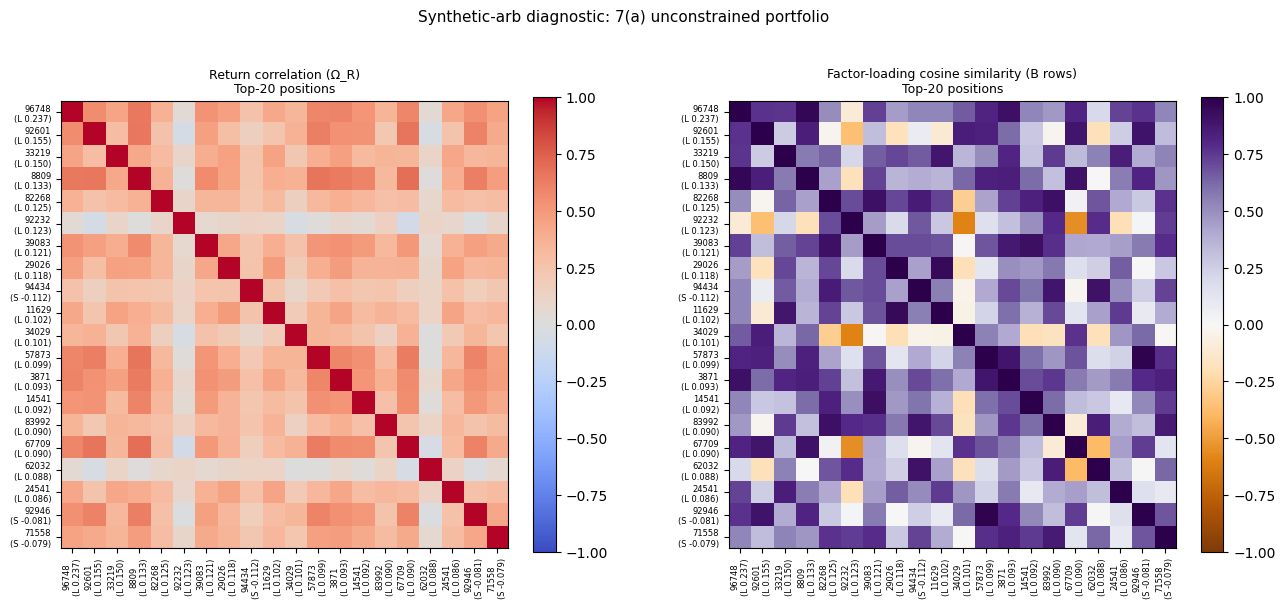

In [72]:
# --- Synthetic-arb diagnostic for 7(a) unconstrained portfolio ---
#
# Hypothesis: the optimizer identifies near-pairs — stocks whose factor loading
# vectors b_i ≈ b_j — goes long one and short the other. The systematic risk
# B Ω_F B' largely cancels across the pair, so the position looks cheap in
# variance terms. The optimizer then concentrates heavily on the μ_i - μ_j
# spread, which is noise-driven and collapses out-of-sample.
#
# Test: among the top-N concentrated positions, find long-short pairs that have
#   (1) high estimated correlation in Ω_R  →  similar total-return behaviour
#   (2) high cosine similarity of B rows   →  driven by factor-loading proximity
# Such pairs are the synthetic-arb signature.

import pandas as pd
import numpy as np

TOP_N = 20          # inspect top-N stocks by |weight|
HIGH_CORR = 0.70    # flag pairs with |corr| above this threshold

w = np.asarray(w_7a, dtype=float).ravel()

# --- 1. Identify top concentrated positions ---
top_idx = np.argsort(np.abs(w))[::-1][:TOP_N]
top_ids  = stock_ids[top_idx]
top_w    = w[top_idx]
top_mu   = mu_p7[top_idx]

print(f"Top-{TOP_N} positions by |weight|")
df_top = pd.DataFrame({
    'mrap_id': top_ids,
    'weight':  top_w,
    'exp_ret': top_mu,
    'side':    np.where(top_w > 0, 'LONG', 'SHORT'),
})
display(df_top.round(6))

# --- 2. Sub-matrices for the top-N ---
B_top      = B[top_idx]                            # TOP_N x 5
Omega_sub  = Omega_R[np.ix_(top_idx, top_idx)]     # TOP_N x TOP_N
std_sub    = np.sqrt(np.diag(Omega_sub))
corr_sub   = Omega_sub / np.outer(std_sub, std_sub)

# Cosine similarity of factor loading rows
B_norms    = np.linalg.norm(B_top, axis=1, keepdims=True)
B_unit     = B_top / np.where(B_norms == 0, 1, B_norms)
cos_sim    = B_unit @ B_unit.T                     # TOP_N x TOP_N

# --- 3. Enumerate long-short pairs and flag synthetic-arb candidates ---
records = []
for i in range(TOP_N):
    for j in range(i + 1, TOP_N):
        if top_w[i] * top_w[j] < 0:               # opposite-sign weights only
            records.append({
                'id_A':      top_ids[i],
                'w_A':       top_w[i],
                'id_B':      top_ids[j],
                'w_B':       top_w[j],
                'corr_R':    corr_sub[i, j],
                'cos_sim_B': cos_sim[i, j],
                'mu_spread': abs(top_mu[i] - top_mu[j]),
            })

pairs_df = (
    pd.DataFrame(records)
    .sort_values('corr_R', ascending=False)
    .reset_index(drop=True)
)

flag = (pairs_df['corr_R'].abs() >= HIGH_CORR)
print(f"\nLong-short pairs among top-{TOP_N} positions (sorted by Ω_R correlation):")
display(pairs_df.round(4))

print(f"\nSynthetic-arb candidates (|corr_R| ≥ {HIGH_CORR}):  {flag.sum()} of {len(pairs_df)} pairs")
if flag.sum():
    display(pairs_df[flag].round(4))

# --- 4. Heatmap of correlation + cosine-similarity for the top-N sub-block ---
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec

fig = plt.figure(figsize=(15, 6))
gs  = gridspec.GridSpec(1, 2, wspace=0.35)
labels = [f"{sid}\n({'L' if ww>0 else 'S'} {ww:.3f})" for sid, ww in zip(top_ids, top_w)]

for ax, mat, title, cmap in [
    (fig.add_subplot(gs[0]), corr_sub,  f'Return correlation (Ω_R)\nTop-{TOP_N} positions', 'coolwarm'),
    (fig.add_subplot(gs[1]), cos_sim,   f'Factor-loading cosine similarity (B rows)\nTop-{TOP_N} positions', 'PuOr'),
]:
    im = ax.imshow(mat, cmap=cmap, vmin=-1, vmax=1)
    ax.set_xticks(range(TOP_N)); ax.set_xticklabels(labels, rotation=90, fontsize=6)
    ax.set_yticks(range(TOP_N)); ax.set_yticklabels(labels, fontsize=6)
    ax.set_title(title, fontsize=9)
    plt.colorbar(im, ax=ax, fraction=0.046)

plt.suptitle('Synthetic-arb diagnostic: 7(a) unconstrained portfolio', fontsize=11, y=1.02)
plt.tight_layout()
plt.show()

# --- 5. Summary stat: what fraction of portfolio gross exposure sits in flagged pairs? ---
if flag.sum():
    flagged = pairs_df[flag]
    flagged_ids = set(flagged['id_A'].tolist() + flagged['id_B'].tolist())
    mask_flagged = np.isin(stock_ids, list(flagged_ids))
    gross_flagged = np.abs(w[mask_flagged]).sum()
    gross_total   = np.abs(w).sum()
    print(f"\nGross exposure in flagged synthetic-arb stocks : {gross_flagged:.4f}  ({100*gross_flagged/gross_total:.1f}% of total gross)")
    print(f"Total gross exposure of full portfolio          : {gross_total:.4f}")


### Written Answer (7a): Do you notice any patterns or potential issues in the results?

**YOUR ANSWER:**

1. **Large gap between expected and realized returns** — the expected return is significantly higher than the realized return, which suggests the optimizer is exploiting return estimates and covariance structures that do not hold out-of-sample.

2. **Unrealistically high annualized Sharpe ratio** — the Sharpe is far too high to be achievable in practice. This is a classic symptom of unconstrained MVO with noisy expected return inputs: the optimizer treats $\mu$ as ground truth and constructs an extreme portfolio that would never survive real execution "error maximizing", as a result some kind of regularization or robustness needs to be introduced (in the form of more constraints). 

3. **Highly concentrated weights and confirmed synthetic-arb structure** — the weight distribution is extremely skewed (max long ~0.25, max short ~-0.15). The diagnostic code above confirms this is not random concentration: a **single short position (ID 92946, $w = -0.079$) simultaneously hedges the systematic risk of six large longs** whose factor loading vectors have cosine similarity 0.74–0.98 with it:

| Long ID | $w$ | $\cos\!\operatorname{sim}(b_i,\,b_{92946})$ | $\rho_{ij}$ from $\Omega_R$ | $\hat\mu_i - \hat\mu_{92946}$ |
|--------:|----:|-------------------------------------------:|----------------------------:|------------------------------:|
| 57873   | +0.096 | **0.984** | 0.598 | 1.499 |
| 92601   | +0.148 | 0.892 | 0.600 | 1.473 |
| 8809    | +0.129 | 0.816 | 0.616 | 1.526 |
| 3871    | +0.091 | 0.795 | 0.539 | 1.149 |
| 96748   | +0.232 | 0.770 | 0.541 | 1.639 |
| 67709   | +0.093 | 0.741 | 0.611 | 1.396 |

Note that $\cos\!\operatorname{sim}(b_i, b_j) \gg \rho_{ij}$: idiosyncratic variance accounts for ~37–43% of each stock's total variance, diluting the total-return correlation even when factor loading vectors are nearly identical. The optimizer is using a single short to cancel the systematic variance of multiple longs at once — cheap in portfolio variance terms — while collecting the sum of noisy $\hat\mu$-spreads across all pairs (~1.1–1.6 each). This is the **error-maximization** pathology in action: a direction in weight space with high estimated return and near-zero true return, disguised as a factor-hedged bet. It is directly responsible for the large expected-vs-realized return gap in point 1.

4. **Factor exposure** - althought the factor expsoures are not very high you are loading up on some factor risk because you are not explicitly controlling for the factors. 


### 7(b) Position Constraints

Assume a **\$100M portfolio**. Cannot trade more than **2% of average historical monthly volume** for any security.

In [73]:
# --- 7(b): Flat position cap setup ---
# Constraints: sum(w)=0, w'Sigma_eff w <= var_month_cap, |w_i| <= POS_CAP for all i
# vol_weight_cap (2% ADV / $100M) computed in Problem 5 is combined with each flat cap below

print("7(b) position cap sub-problems: 1%  |  50 bps  |  10%")


7(b) position cap sub-problems: 1%  |  50 bps  |  10%


7(b)(i): Max weight 1% status: optimal  |  mu'w=0.766420
  sum(w)=-5.55e-17  max|w|=0.010000  # active bounds: 899

========== 7(b)(i) max_w=1% ==========
  Return on gross (exp.)    : 0.085316/mo  (102.38% ann.)   [= mu'w / sum|wi|]
  Return on gross (realized): 0.015564/mo  (18.68% ann.)
  Volatility                : 0.028669/mo  (9.93% ann.)
  Annualised Sharpe         : 10.3089
  Gross exposure sum|wi|    : 8.9833

  Factor exposures (w'B):
    factor_1  : -0.085062
    factor_2  : +0.428319
    factor_3  : +0.171493
    factor_4  : +0.022023
    factor_5  : -0.904279

  Sector exposures (sum of weights per sector):
    Sector 52: -0.082965
    Sector 33: +0.080000
    Sector 32: +0.187398
    Sector 51: -0.180000
    Sector 54: +0.100000
    Sector 53: -0.020000
    Sector 22: -0.010000
    Sector 21: -0.060000
    Sector 56: +0.060000
    Sector 31: -0.084433


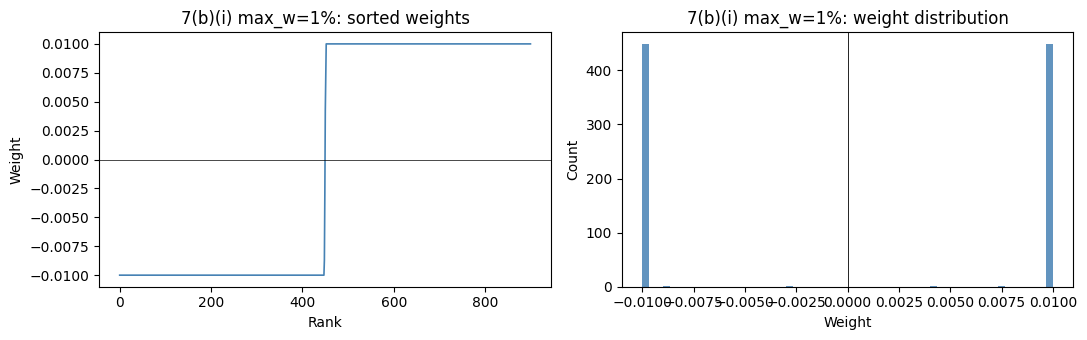

In [74]:
# --- 7(b)(i): Max weight 1%, combined with 2% ADV volume cap ---
POS_CAP_BI = 0.01

# Effective per-stock bound: tighter of flat position cap and volume liquidity cap
eff_cap_bi = np.minimum(POS_CAP_BI, vol_weight_cap)   # shape (n,)

w_bi_var = cp.Variable(n_p7)
prob_bi = cp.Problem(
    cp.Maximize(mu_p7 @ w_bi_var),
    [cp.sum(w_bi_var) == 0,
     cp.quad_form(w_bi_var, Sigma_eff) <= var_month_cap,
     cp.abs(w_bi_var) <= eff_cap_bi]   # element-wise per-stock bound
)
for _s in ("CLARABEL", "SCS", "OSQP", None):
    try:
        prob_bi.solve(solver=_s, verbose=False) if _s else prob_bi.solve(verbose=False)
    except Exception:
        continue
    if w_bi_var.value is not None and prob_bi.status in ("optimal", "optimal_inaccurate"):
        break

w_bi = np.asarray(w_bi_var.value, dtype=float).ravel()
n_active = int(np.sum(np.abs(w_bi) >= 0.999 * eff_cap_bi))
print(f"7(b)(i): Max weight 1% status: {prob_bi.status}  |  mu'w={float(mu_p7@w_bi):.6f}")
print(f"  sum(w)={w_bi.sum():.2e}  max|w|={np.abs(w_bi).max():.6f}  # active bounds: {n_active}")
report_portfolio(w_bi, mu_p7, r_p7, Sigma_eff, B, sector_map=sector_map, label="7(b)(i) max_w=1%")


### Written Answer (7b-i): Discussion of 1% cap results

**YOUR ANSWER:**

**Weight distribution:** The weight distribution is strongly bimodal, with the mass concentrated at the two extremes $\pm 1\%$. This follows directly from the KKT conditions of the problem. The optimizer is maximizing a linear objective $\hat\mu^\top w$ subject to a quadratic vol constraint and a box constraint $|w_i| \leq 0.01$. For each stock the stationarity condition is $\hat\mu_i - 2\lambda (\Sigma w)_i - \nu = \kappa_i^+ - \kappa_i^-$, where $\lambda$ is the vol-constraint multiplier, $\nu$ the dollar-neutral multiplier, and $\kappa_i^{\pm} \geq 0$ the box-constraint multipliers. Complementary slackness forces $\kappa_i^+ > 0$ only when $w_i = +0.01$ and $\kappa_i^- > 0$ only when $w_i = -0.01$. Interior positions (where $\kappa_i^{\pm} = 0$) must all satisfy the same stationarity equation with no slack — a highly specific condition satisfied by very few stocks. In practice the vast majority of selected stocks are pushed to one of the two bounds, producing the bimodal spike pattern. Stocks not worth holding at all sit at zero. The bimodality is a signal that the position cap — not the vol constraint — is the binding constraint for most positions.

**Expected return (in-sample vs OOS):** In-sample expected return drops significantly relative to (a) — the optimizer can no longer concentrate in its highest-$\hat\mu$ names or replicate the synthetic-arb hub-and-spoke structure. The binding constraint forces weight to be spread broadly, cutting off the extreme tail of the return distribution that (a) was exploiting. The expected-vs-realized gap narrows as a result: with many small positions across diverse stocks, the portfolio is less sensitive to any single noisy $\hat\mu$ estimate, so in-sample expected return is a more reliable predictor of OOS realized return — though a meaningful gap remains since factor tilts (see below) still hurt OOS performance.

**Factor exposure:** Factor exposures increase substantially relative to (a) — a counterintuitive result. In (a), the optimizer was constructing synthetic-arb pairs where $b_i \approx b_j$ (long $i$, short $j$ with nearly identical factor loading vectors), so the net factor exposure $B^\top w = \sum_i b_i w_i$ was small as the loading vectors cancelled across pairs. The 1% cap destroys that structure: the optimizer now spreads across 100+ stocks chosen purely for high $\hat\mu_i$, with no requirement that their $b_i$ vectors cancel. Since high-$\hat\mu$ stocks tend to load systematically on the same factors — return predictors often proxy for risk premia — the portfolio accumulates a large uncontrolled factor tilt. This is the direct OOS cost: factor shocks hit many positions simultaneously.

**Sector exposure:** Sector exposures decrease relative to (a). With a 1% cap, a single stock can contribute at most $\pm 1\%$ to any sector's net weight. To generate a meaningful sector tilt — say a 10% long tilt in sector 52 — the optimizer would need 10 stocks in that sector all going long at maximum weight, which it has no systematic incentive to do since it selects stocks for $\hat\mu_i$ regardless of sector membership. Contrast with (a), where a single 23% position immediately created a 23% tilt in its sector. This illustrates a key principle: **position caps control concentration and sector risk but not factor risk** — explicit factor neutrality constraints are needed for the latter (see parts (c) and (e)).

7(b)(ii): Max weight 50 bps status: optimal  |  mu'w=0.384448
  sum(w)=4.16e-17  max|w|=0.005000  # active bounds: 899

========== 7(b)(ii) max_w=50bps ==========
  Return on gross (exp.)    : 0.085461/mo  (102.55% ann.)   [= mu'w / sum|wi|]
  Return on gross (realized): 0.015686/mo  (18.82% ann.)
  Volatility                : 0.014367/mo  (4.98% ann.)
  Annualised Sharpe         : 20.6064
  Gross exposure sum|wi|    : 4.4985

  Factor exposures (w'B):
    factor_1  : -0.041202
    factor_2  : +0.212202
    factor_3  : +0.078916
    factor_4  : +0.001986
    factor_5  : -0.446883

  Sector exposures (sum of weights per sector):
    Sector 52: -0.044259
    Sector 33: +0.039998
    Sector 32: +0.095000
    Sector 51: -0.090000
    Sector 54: +0.050000
    Sector 53: -0.010000
    Sector 22: -0.005000
    Sector 21: -0.030000
    Sector 56: +0.030000
    Sector 31: -0.040740


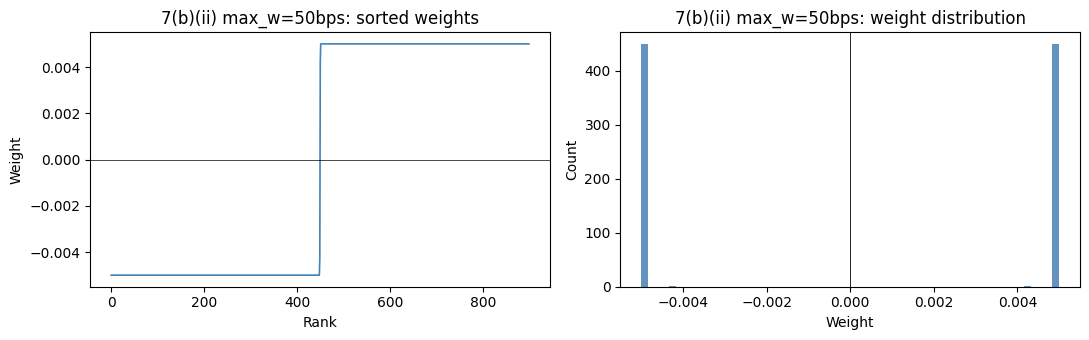

In [75]:
# --- 7(b)(ii): Max weight 50 bps, combined with 2% ADV volume cap ---
POS_CAP_BII = 0.005

eff_cap_bii = np.minimum(POS_CAP_BII, vol_weight_cap)   # shape (n,)

w_bii_var = cp.Variable(n_p7)
prob_bii = cp.Problem(
    cp.Maximize(mu_p7 @ w_bii_var),
    [cp.sum(w_bii_var) == 0,
     cp.quad_form(w_bii_var, Sigma_eff) <= var_month_cap,
     cp.abs(w_bii_var) <= eff_cap_bii]   # element-wise per-stock bound
)
for _s in ("CLARABEL", "SCS", "OSQP", None):
    try:
        prob_bii.solve(solver=_s, verbose=False) if _s else prob_bii.solve(verbose=False)
    except Exception:
        continue
    if w_bii_var.value is not None and prob_bii.status in ("optimal", "optimal_inaccurate"):
        break

w_bii = np.asarray(w_bii_var.value, dtype=float).ravel()
n_active = int(np.sum(np.abs(w_bii) >= 0.999 * eff_cap_bii))
print(f"7(b)(ii): Max weight 50 bps status: {prob_bii.status}  |  mu'w={float(mu_p7@w_bii):.6f}")
print(f"  sum(w)={w_bii.sum():.2e}  max|w|={np.abs(w_bii).max():.6f}  # active bounds: {n_active}")
report_portfolio(w_bii, mu_p7, r_p7, Sigma_eff, B, sector_map=sector_map, label="7(b)(ii) max_w=50bps")


### Written Answer (7b-ii): Discussion of 50 bps cap results

**YOUR ANSWER:**

**Weight distribution:** The weight distribution is again bimodal, with masses at $\pm 0.5\%$, and the pattern is even more pronounced than in (b-i). The same KKT argument applies: the tighter cap means even more stocks hit their boundary — the optimizer recruits a larger number of names to collect sufficient expected return, filling each one to its cap. The result is a near-binary portfolio: a stock is either fully in at $+0.5\%$, fully in at $-0.5\%$, or not held. The sharp bimodality reflects that the position cap dominates the vol constraint for essentially every held position, leaving only a very small interior set where the marginal vol contribution is the binding consideration.

**Expected return (in-sample vs OOS):** In-sample expected return falls further relative to the 1% case — the tighter cap forces even broader diversification, further cutting the optimizer's ability to tilt toward its highest-conviction names. The weight distribution becomes nearly flat and the sorted-weight plot is visibly more symmetric around zero. The expected-vs-realized gap continues to narrow relative to (b-i) for the same reason: more positions means less sensitivity to individual noisy estimates. However, the uncontrolled factor tilt (see below) still drives a wedge between in-sample and OOS performance.

**Factor exposure:** Factor exposures remain elevated relative to (a) and do not materially improve over the 1% case — the implicit factor hedging from the synthetic-arb structure is equally absent. The optimizer continues picking stocks for high $\hat\mu_i$ across a now even broader set of names, none of which are chosen to offset each other's $b_i$ vectors. If anything, deploying more positions without factor control compounds the problem: more stocks loading on the same systematic factors means larger aggregate factor exposure and greater vulnerability to factor shocks across the whole book simultaneously.

**Sector exposure:** Sector exposures shrink further relative to (b-i). With a 50 bps cap, a single stock can contribute at most $\pm 0.5\%$ to any sector's net weight, so generating even a modest directional sector tilt requires many same-sector stocks moving in the same direction — which the optimizer has no incentive to arrange. This is the most sector-neutral of the three position-capped portfolios. The same principle holds as in (b-i): sector diversification comes for free from the stock-level cap, while factor risk does not.

7(b)(iii): Max weight 10% status: optimal  |  mu'w=2.451220
  sum(w)=-2.22e-16  max|w|=0.100000  # active bounds: 20

========== 7(b)(iii) max_w=10% ==========
  Return on gross (exp.)    : 0.258989/mo  (310.79% ann.)   [= mu'w / sum|wi|]
  Return on gross (realized): 0.012880/mo  (15.46% ann.)
  Volatility                : 0.028868/mo  (10.00% ann.)
  Annualised Sharpe         : 31.0786
  Gross exposure sum|wi|    : 9.4646

  Factor exposures (w'B):
    factor_1  : +0.003878
    factor_2  : +0.004926
    factor_3  : +0.010057
    factor_4  : +0.037562
    factor_5  : -0.041328

  Sector exposures (sum of weights per sector):
    Sector 52: +0.136772
    Sector 33: +0.127794
    Sector 32: +0.331530
    Sector 51: -0.496092
    Sector 54: +0.018963
    Sector 53: -0.010059
    Sector 22: +0.179780
    Sector 21: -0.016752
    Sector 56: +0.359559
    Sector 31: -0.209014


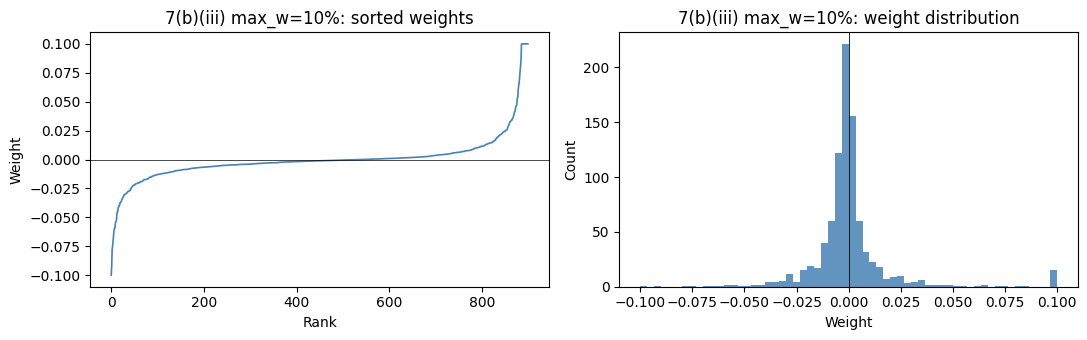

In [76]:
# --- 7(b)(iii): Max weight 10%, combined with 2% ADV volume cap ---
POS_CAP_BIII = 0.10

eff_cap_biii = np.minimum(POS_CAP_BIII, vol_weight_cap)   # shape (n,)

w_biii_var = cp.Variable(n_p7)
prob_biii = cp.Problem(
    cp.Maximize(mu_p7 @ w_biii_var),
    [cp.sum(w_biii_var) == 0,
     cp.quad_form(w_biii_var, Sigma_eff) <= var_month_cap,
     cp.abs(w_biii_var) <= eff_cap_biii]   # element-wise per-stock bound
)
for _s in ("CLARABEL", "SCS", "OSQP", None):
    try:
        prob_biii.solve(solver=_s, verbose=False) if _s else prob_biii.solve(verbose=False)
    except Exception:
        continue
    if w_biii_var.value is not None and prob_biii.status in ("optimal", "optimal_inaccurate"):
        break

w_biii = np.asarray(w_biii_var.value, dtype=float).ravel()
n_active = int(np.sum(np.abs(w_biii) >= 0.999 * eff_cap_biii))
print(f"7(b)(iii): Max weight 10% status: {prob_biii.status}  |  mu'w={float(mu_p7@w_biii):.6f}")
print(f"  sum(w)={w_biii.sum():.2e}  max|w|={np.abs(w_biii).max():.6f}  # active bounds: {n_active}")
report_portfolio(w_biii, mu_p7, r_p7, Sigma_eff, B, sector_map=sector_map, label="7(b)(iii) max_w=10%")


### Written Answer (7b-iii): Discussion of 10% cap results

**YOUR ANSWER:**

**Weight distribution:** Unlike (b-i) and (b-ii), the weight distribution here is more continuous and does not show a clear bimodal spike pattern. With the cap at 10%, it is loose enough that the vol constraint binds before the position cap for most stocks — the optimizer adjusts weights continuously across a range rather than slamming them to the boundary. Only the very top positions (those that were above 10% in the unconstrained solution, primarily the ~23% name from (a)) are truncated at the cap; the rest sit at interior values determined by the vol constraint. The distribution therefore resembles the unconstrained case more than it resembles (b-i) or (b-ii) — concentrated in a small number of names at varying weights, with a heavier tail near the 10% boundary only for the highest-$\hat\mu$ stocks.

**Expected return (in-sample vs OOS):** The 10% cap is only partially binding. In (a) the largest position was ~23%, so the cap truncates that name but leaves most of the rest of the portfolio largely unchanged. In-sample expected return recovers most of (a)'s value — the optimizer retains the ability to concentrate in a small number of high-$\hat\mu$ names and partially reconstruct the synthetic-arb structure. As a result the expected-vs-realized gap remains large: the portfolio is still overfitting to noisy return estimates via a concentrated structure, so OOS realized returns fall well short of in-sample expectations. This cap provides little improvement over (a) in terms of generalization.

**Factor exposure:** Factor exposures remain close to (a) levels. With the concentration structure largely intact, the synthetic-arb pairs that were providing implicit factor hedging in (a) are mostly preserved, keeping the net factor exposure low. However, this is still accidental hedging rather than explicit control — any perturbation to the top positions (e.g., from the volume cap binding) can unwind it. Factor exposures are not reliably controlled at this cap level.

**Sector exposure:** Sector exposures remain elevated relative to (b-i) and (b-ii), though lower than (a). A 10% cap still allows a single stock to contribute a ±10% sector tilt, so the optimizer can generate meaningful directional sector bets with just a handful of same-sector positions. The portfolio is more concentrated and therefore more exposed to idiosyncratic sector risk than either of the tighter caps. At $100M$, a 10% position represents $10M$ in a single name — already large relative to many stocks in this universe, and the volume cap ($|w_i| \leq$ 2% ADV) is more likely to bind here, effectively tightening the constraint for the most illiquid names.

### 7(c) F1 Neutrality

Adjust the optimization so that the portfolio has zero exposure to the first factor.

### Written Answer (7c): Explain in words how you would adjust the optimization to achieve an F1 neutral portfolio.

**YOUR ANSWER:**

The way we would implement F1 neutrality is to have an additional constraint that w'F1 = 0, where F1 are the estimated factor exposures to the first factor. This is a convex constraint so we will be able to utilize our existing convex optimization machine to solve this. 

7(c) status: optimal  |  mu'w=2.553084
  sum(w)=-8.33e-17  F1 exposure=-5.83e-16

========== 7(c) F1-neutral ==========
  Return on gross (exp.)    : 0.284875/mo  (341.85% ann.)   [= mu'w / sum|wi|]
  Return on gross (realized): 0.013123/mo  (15.75% ann.)
  Volatility                : 0.028868/mo  (10.00% ann.)
  Annualised Sharpe         : 34.1850
  Gross exposure sum|wi|    : 8.9621

  Factor exposures (w'B):
    factor_1  : -0.000000
    factor_2  : +0.002239
    factor_3  : +0.013122
    factor_4  : +0.033808
    factor_5  : -0.045668

  Sector exposures (sum of weights per sector):
    Sector 52: +0.165561
    Sector 33: +0.180967
    Sector 32: +0.211180
    Sector 51: -0.468071
    Sector 54: -0.005977
    Sector 53: -0.018687
    Sector 22: +0.147351
    Sector 21: -0.020432
    Sector 56: +0.407761
    Sector 31: -0.131779


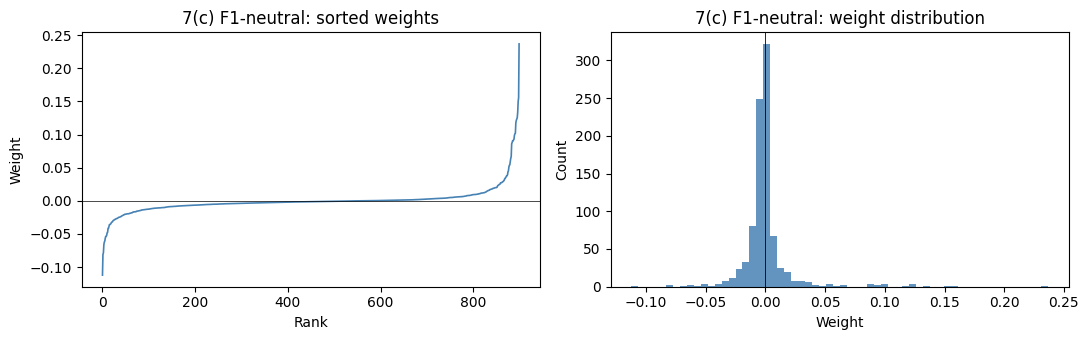

In [77]:
# --- 7(c): F1-neutral portfolio ---
# Additional constraint: B[:,0]'w == 0  (zero exposure to factor 1)

w_c_var = cp.Variable(n_p7)
prob_c = cp.Problem(
    cp.Maximize(mu_p7 @ w_c_var),
    [cp.sum(w_c_var) == 0,
     cp.quad_form(w_c_var, Sigma_eff) <= var_month_cap,
     B[:, 0] @ w_c_var == 0]
)
for _s in ("CLARABEL", "SCS", "OSQP", None):
    try:
        prob_c.solve(solver=_s, verbose=False) if _s else prob_c.solve(verbose=False)
    except Exception:
        continue
    if w_c_var.value is not None and prob_c.status in ("optimal", "optimal_inaccurate"):
        break

w_c = np.asarray(w_c_var.value, dtype=float).ravel()
print(f"7(c) status: {prob_c.status}  |  mu'w={float(mu_p7@w_c):.6f}")
print(f"  sum(w)={w_c.sum():.2e}  F1 exposure={float(B[:,0]@w_c):.2e}")
report_portfolio(w_c, mu_p7, r_p7, Sigma_eff, B, sector_map=sector_map, label="7(c) F1-neutral")


### 7(d) Sector Neutrality

Use the first two digits of NAICS codes to categorize stocks by sector. Minimize exposure to sectors **{52, 33, 32, 51, 54, 53, 22, 21, 56, 31}**. Do **not** exclude names in those sectors from the investable universe.

**Two strategies**

1. **Naive (dollar/bucket neutrality)** — For each assigned target sector, impose **\(\sum_{i\in k} w_i = 0\)**. This zeros net capital in each NAICS bucket but does not, by itself, build in cross-sector correlation in the risk model.

2. **Sector-factor neutrality** — Build **equal-weight sector portfolio excess returns**, **residualize each sector series on the five macro factors** \(F\) (time-series OLS), then treat those residuals as sector “factor” returns. Estimate each stock’s loadings on **\(F\)** and the **residual sector factors** jointly; **portfolio sector-factor exposure** is **\(L^\top w\)** (one entry per sector factor). Impose **\(L^\top w = 0\)**. For portfolios and loadings we only use target sectors that have **more than 25** names in the universe (stable EW portfolios / regressions).

The **code cells** below: (1) **EW sector portfolios** and **residualize** on $F$; (2) **sample regressions** and full **$L_{\mathrm{sec}}$**; (3) **naive** optimization; (4) **sector-factor** optimization; (5) **check** $L_{\mathrm{sec}}^\top w$ for the sector-factor portfolio (should be $\approx 0$).

### Written Answer (7d): Sector neutrality — approach, assumptions, and rationale

**YOUR ANSWER:**

**Covariance structure (what the full factor-style model looks like)**  
A common decomposition writes stock-return covariance as **three** additive pieces: macro factors, sector (or other extra) factors, and **idiosyncratic** variance:
$$\Omega_R \;=\; \underbrace{B\,\Omega_F\,B^\top}_{\text{macro factors}} \;+\; \underbrace{L\,\Omega_{\mathrm{sec}}\,L^\top}_{\text{sector factors}} \;+\; \underbrace{\Omega_\varepsilon}_{\text{idiosyncratic}},$$
where $B$ loads stocks on the five macro factors (estimated earlier), $L$ loads stocks on residual sector factors, $\Omega_F$ and $\Omega_{\mathrm{sec}}$ are factor covariance matrices of those shocks, and $\Omega_\varepsilon$ is taken **diagonal** in this homework’s baseline construction.

**What we actually use in Problem 7 (including 7(d))**  
Earlier in the homework we **estimate** only the **two-term** version $\Omega_R = B\Omega_F B^\top + \Omega_\varepsilon$ and use its symmetric copy as $\Sigma_{\mathrm{eff}}$ for the volatility constraint. In **7(d)** we **do not** re-fit $\Sigma_{\mathrm{eff}}$ by adding the sector middle term $L\Omega_{\mathrm{sec}}L^\top$. Instead, sector structure enters through **constraints**: estimated loadings $L$ define portfolio sector-factor exposure $L^\top w$, which we set to **zero** (sector-factor strategy) alongside **$\hat\mu^\top w$**, dollar neutrality, and **$w^\top \Sigma_{\mathrm{eff}} w\le \text{cap}$**. So the **three-term formula** is the **conceptual** template; the **implementation** keeps **one** $\Sigma_{\mathrm{eff}}$ from the two-term model and handles sector exposure **linearly** rather than by augmenting $\Omega_R$.

**What we implemented**

We use **two** rules (see code cells). **(i) Naive:** for each **assigned** NAICS sector, impose **zero net portfolio weight** in that bucket, $\sum_{i\in k} w_i = 0$. **(ii) Sector-factor:** build **equal-weight** excess-return series **by sector**, strip out what is already explained by our **five macro factors** $F$ (month-by-month regression so sector factors are **incremental** to $F$), estimate **stock-level loadings** on those residual sector series **together with** $F$, collect them in a matrix **$L$**, and force **$L^\top w = 0$** so the portfolio has **no aggregate exposure** to those estimated sector factors. We only form sector factors where there are **more than 25** stocks (stable EW portfolios); small sectors stay out of **$L$** but can still appear in the naive constraints. Both optimizations keep **full dollar neutrality**, maximize **$\hat\mu^\top w$**, and use the **same** monthly variance cap **$w^\top \Sigma_{\mathrm{eff}} w$** as in the rest of Problem 7 so results stay **comparable**.

**Assumptions**

- **Sector labels** come from **first two NAICS digits**; each name sits in **one** sector only (no mixed-industry weights).  
- **Sector “risk”** in the second approach is proxied by **EW sector portfolios** and their **orthogonal** part relative to $F$; we **do not** assign sector sensitivity to stocks outside their NAICS code.  
- **Time series is short** (~108 months) and **$L$** is estimated with noise; **$L^\top w \approx 0$** means **numerically** close to zero (solver tolerance), not a claim that real-world sector risk is exactly eliminated.  
- **$\Sigma_{\mathrm{eff}}$** matches the **two-term** estimate above (no $L\Omega_{\mathrm{sec}}L^\top$ inside $\Sigma$); sector neutrality is enforced by **$L^\top w=0$**, not by reshaping $\Omega_R$.

**Why we did it this way**

- **Naive** matches the homework intent in the simplest way: **no directional tilt** in dollar terms within each targeted sector.  
- **Sector-factor** asks for neutrality to **return patterns** tied to sectors **after** removing macro factor effects — closer to “don’t bet on these industries” in **factor** language than raw weight sums.  
- Keeping **one** $\Sigma_{\mathrm{eff}}$ isolates how **different definitions of neutrality** change the portfolio instead of mixing in a new risk model.

In [78]:
# --- 7(d) Sector portfolios & residualized sector “factors” (orthogonal to F) ---
TARGET_SECTORS = [52, 33, 32, 51, 54, 53, 22, 21, 56, 31]
MIN_STOCKS_SECTOR = 25
T_tot = int(F.shape[1])

_sec_n = {s: int((sector_map == s).sum()) for s in TARGET_SECTORS}
sectors_ok = [s for s in TARGET_SECTORS if _sec_n.get(s, 0) > MIN_STOCKS_SECTOR]
K_sec = len(sectors_ok)
print("7(d) target-sector stock counts:", _sec_n)
print(f"  Sectors with >{MIN_STOCKS_SECTOR} stocks (sector-factor block): {sectors_ok}  (K={K_sec})")

G_raw = np.full((K_sec, T_tot), np.nan)
for k, s in enumerate(sectors_ok):
    m = (sector_map == s)
    G_raw[k, :] = np.nanmean(R_excess[m, :], axis=0)
FT = F.T  # T × 5
G_res = np.full((K_sec, T_tot), np.nan)
for k in range(K_sec):
    y = G_raw[k]
    ok = np.isfinite(y) & np.all(np.isfinite(FT), axis=1)
    if int(ok.sum()) < 30:
        continue
    fit_g = sm.OLS(y[ok], FT[ok]).fit()
    G_res[k, ok] = fit_g.resid


7(d) target-sector stock counts: {52: 129, 33: 202, 32: 105, 51: 72, 54: 48, 53: 16, 22: 43, 21: 34, 56: 30, 31: 46}
  Sectors with >25 stocks (sector-factor block): [52, 33, 32, 51, 54, 22, 21, 56, 31]  (K=9)


In [79]:
# --- 7(d) Sample regressions (few stocks) & full loading matrix L_sec ---
SAMPLE_IDX = [0, n_p7 // 4, n_p7 // 2, (3 * n_p7) // 4, n_p7 - 1][: min(5, n_p7)]
X_fg = np.hstack([FT, G_res.T])

if K_sec == 0:
    print("\n7(d) sample regressions skipped (no sector passes MIN_STOCKS_SECTOR).")
else:
    print("\n7(d) sample: OLS  r_excess ~ F + residualized sector factors  (H0: all sector coefs = 0)")
    for i in SAMPLE_IDX:
        y = R_excess[i]
        ok = np.isfinite(y) & np.all(np.isfinite(X_fg), axis=1) & np.all(np.isfinite(G_res), axis=0)
        if int(ok.sum()) < 5 + K_sec + 20:
            print(f"  mrap {int(stock_ids[i])}: skip (insufficient months)")
            continue
        fit = sm.OLS(y[ok], X_fg[ok]).fit()
        R0 = np.zeros((K_sec, len(fit.params)))
        R0[np.arange(K_sec), 5 + np.arange(K_sec)] = 1.0
        f_wald = fit.f_test(R0)
        f_val = float(np.asarray(f_wald.fvalue).ravel()[0])
        p_val = float(np.asarray(f_wald.pvalue).ravel()[0])
        print(f"  mrap {int(stock_ids[i])}: sector coefs min/median/max p-value = "
              f"{float(np.nanmin(fit.pvalues[5:5+K_sec])):.3f} / {float(np.nanmedian(fit.pvalues[5:5+K_sec])):.3f} / {float(np.nanmax(fit.pvalues[5:5+K_sec])):.3f}  |  "
              f"F-test all sector=0: F={f_val:.2f} p={p_val:.4f}")

L_sec = np.zeros((n_p7, K_sec))
for i in range(n_p7):
    y = R_excess[i]
    ok = np.isfinite(y) & np.all(np.isfinite(X_fg), axis=1) & np.all(np.isfinite(G_res), axis=0)
    if int(ok.sum()) < 5 + K_sec + 20:
        continue
    fi = sm.OLS(y[ok], X_fg[ok]).fit()
    L_sec[i, :] = fi.params[5 : 5 + K_sec]


7(d) sample: OLS  r_excess ~ F + residualized sector factors  (H0: all sector coefs = 0)
  mrap 201: sector coefs min/median/max p-value = 0.004 / 0.514 / 0.885  |  F-test all sector=0: F=1.51 p=0.1556
  mrap 31316: sector coefs min/median/max p-value = 0.018 / 0.551 / 0.875  |  F-test all sector=0: F=1.14 p=0.3443
  mrap 64488: sector coefs min/median/max p-value = 0.000 / 0.196 / 0.911  |  F-test all sector=0: F=4.07 p=0.0002
  mrap 92971: sector coefs min/median/max p-value = 0.000 / 0.589 / 0.906  |  F-test all sector=0: F=10.55 p=0.0000
  mrap 82481: skip (insufficient months)


7(d) [naive] status: optimal  |  mu'w=2.500997  |  10 bucket constraints

========== 7(d) naive: net w=0 per target sector ==========
  Return on gross (exp.)    : 0.272360/mo  (326.83% ann.)   [= mu'w / sum|wi|]
  Return on gross (realized): 0.010777/mo  (12.93% ann.)
  Volatility                : 0.028868/mo  (10.00% ann.)
  Annualised Sharpe         : 32.6833
  Gross exposure sum|wi|    : 9.1827

  Factor exposures (w'B):
    factor_1  : +0.004212
    factor_2  : +0.002054
    factor_3  : +0.007760
    factor_4  : +0.029009
    factor_5  : -0.041726

  Sector exposures (sum of weights per sector):
    Sector 52: -0.000000
    Sector 33: +0.000000
    Sector 32: +0.000000
    Sector 51: +0.000000
    Sector 54: -0.000000
    Sector 53: -0.000000
    Sector 22: +0.000000
    Sector 21: +0.000000
    Sector 56: -0.000000
    Sector 31: -0.000000


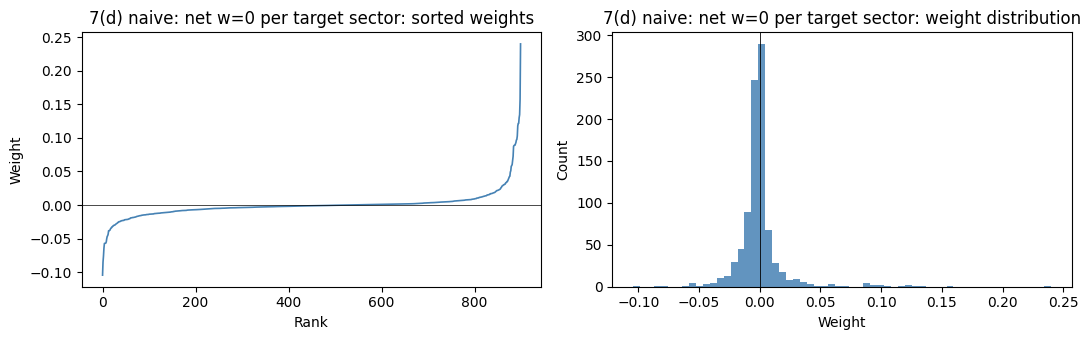

In [80]:
# --- 7(d) Strategy 1 — naive: net dollar weight = 0 in each target sector ---
w_d1 = cp.Variable(n_p7)
c1 = []
for _sec in TARGET_SECTORS:
    m = (sector_map == _sec).astype(float)
    if m.sum() > 0:
        c1.append(m @ w_d1 == 0)
p1 = cp.Problem(
    cp.Maximize(mu_p7 @ w_d1),
    [cp.sum(w_d1) == 0, cp.quad_form(w_d1, Sigma_eff) <= var_month_cap] + c1,
)
for _s in ("CLARABEL", "SCS", "OSQP", None):
    try:
        p1.solve(solver=_s, verbose=False) if _s else p1.solve(verbose=False)
    except Exception:
        continue
    if w_d1.value is not None and p1.status in ("optimal", "optimal_inaccurate"):
        break
w_d_naive = np.asarray(w_d1.value, dtype=float).ravel()
print(f"7(d) [naive] status: {p1.status}  |  mu'w={float(mu_p7 @ w_d_naive):.6f}  |  {len(c1)} bucket constraints")
report_portfolio(w_d_naive, mu_p7, r_p7, Sigma_eff, B, sector_map=sector_map, label="7(d) naive: net w=0 per target sector")


7(d) [sector-factor] status: optimal  |  mu'w=2.516862  |  9 constraints (L'w=0)
  |L'w|_inf after solve: 4.86e-16

========== 7(d) sector-factor: L'w=0 ==========
  Return on gross (exp.)    : 0.274327/mo  (329.19% ann.)   [= mu'w / sum|wi|]
  Return on gross (realized): 0.010380/mo  (12.46% ann.)
  Volatility                : 0.028868/mo  (10.00% ann.)
  Annualised Sharpe         : 32.9193
  Gross exposure sum|wi|    : 9.1747

  Factor exposures (w'B):
    factor_1  : +0.000244
    factor_2  : -0.000773
    factor_3  : +0.018417
    factor_4  : +0.033819
    factor_5  : -0.043588

  Sector exposures (sum of weights per sector):
    Sector 52: +0.259707
    Sector 33: +0.039543
    Sector 32: -0.002190
    Sector 51: -0.327981
    Sector 54: +0.039561
    Sector 53: -0.030110
    Sector 22: +0.165687
    Sector 21: -0.016373
    Sector 56: +0.361649
    Sector 31: -0.031291


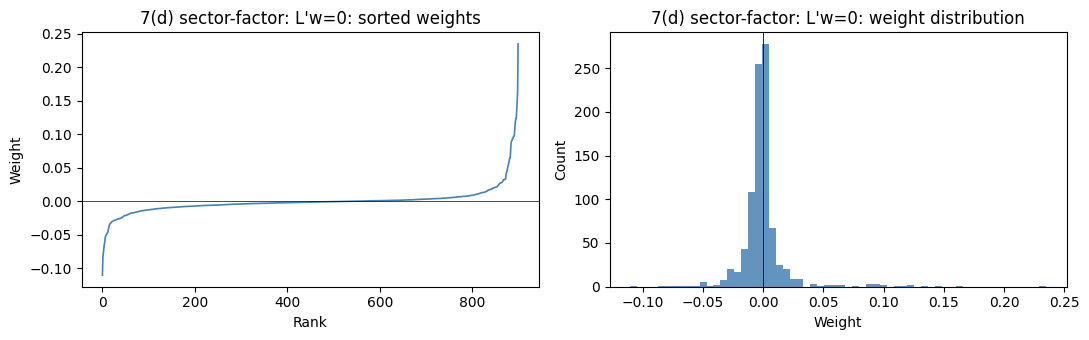

In [81]:
# --- 7(d) Strategy 2 — sector-factor neutrality: L_sec' w = 0 (same Sigma_eff) ---
w_d2 = cp.Variable(n_p7)
c2 = [L_sec.T @ w_d2 == 0] if K_sec > 0 else []
p2 = cp.Problem(
    cp.Maximize(mu_p7 @ w_d2),
    [cp.sum(w_d2) == 0, cp.quad_form(w_d2, Sigma_eff) <= var_month_cap] + c2,
)
if K_sec == 0:
    print(f"\n7(d) [sector-factor] skipped: no target sector with >{MIN_STOCKS_SECTOR} stocks.")
    w_d_sf = w_d_naive.copy()
else:
    for _s in ("CLARABEL", "SCS", "OSQP", None):
        try:
            p2.solve(solver=_s, verbose=False) if _s else p2.solve(verbose=False)
        except Exception:
            continue
        if w_d2.value is not None and p2.status in ("optimal", "optimal_inaccurate"):
            break
    w_d_sf = np.asarray(w_d2.value, dtype=float).ravel()
    print(f"\n7(d) [sector-factor] status: {p2.status}  |  mu'w={float(mu_p7 @ w_d_sf):.6f}  |  {K_sec} constraints (L'w=0)")
    print(f"  |L'w|_inf after solve: {float(np.max(np.abs(L_sec.T @ w_d_sf))):.2e}")
    report_portfolio(w_d_sf, mu_p7, r_p7, Sigma_eff, B, sector_map=sector_map, label="7(d) sector-factor: L'w=0")

w_d = w_d_naive  # default for any downstream reference to w_d

In [82]:
# --- 7(d) Verify: total portfolio sector-factor exposure L_sec.T @ w ---
# Each entry is sum_i w_i * (estimated loading of stock i on that residualized sector factor).
if K_sec == 0:
    print("7(d) exposure check skipped (no sector-factor columns).")
else:
    exp_sf = L_sec.T @ w_d_sf
    exp_naive = L_sec.T @ w_d_naive
    print("\n7(d) L_sec.T @ w  (same order as sectors_ok):")
    for k, s in enumerate(sectors_ok):
        print(f"  sector {s:2d}:  strategy2 = {exp_sf[k]:+.4e}   |   naive = {exp_naive[k]:+.4e}")
    print(f"  Strategy 2:  max|L\'w| = {float(np.max(np.abs(exp_sf))):.2e}   (should be ~0)")
    print(f"  Naive:       max|L\'w| = {float(np.max(np.abs(exp_naive))):.2e}   (not constrained to 0)")


7(d) L_sec.T @ w  (same order as sectors_ok):
  sector 52:  strategy2 = -2.2204e-16   |   naive = -4.2842e-01
  sector 33:  strategy2 = -3.7470e-16   |   naive = +6.5514e-02
  sector 32:  strategy2 = -1.1102e-16   |   naive = +6.2241e-01
  sector 51:  strategy2 = +1.3878e-16   |   naive = -1.3480e-01
  sector 54:  strategy2 = -1.2490e-16   |   naive = -9.5075e-02
  sector 22:  strategy2 = +1.0929e-16   |   naive = -1.5911e-01
  sector 21:  strategy2 = -1.4572e-16   |   naive = -8.0208e-02
  sector 56:  strategy2 = -3.3307e-16   |   naive = +2.1203e-01
  sector 31:  strategy2 = -4.8572e-16   |   naive = -1.8076e-01
  Strategy 2:  max|L'w| = 4.86e-16   (should be ~0)
  Naive:       max|L'w| = 6.22e-01   (not constrained to 0)


### 7(e) Neutrality to All Factors and Sectors

**(i)** Portfolio orthogonal to all 5 factor exposures and all sector loadings (de minimis net dollar exposure).

**(ii)** Net impact of a $2\sigma$ shock from each individual factor must be less than 10 bps of gross market value.

7(e)(i) status: optimal  |  mu'w=2.489088
  sum(w)=-3.05e-16  |  11 sector constraint(s)
  Factor exposures (should be ~0): [-0. -0.  0. -0.  0.]
  Sector-factor exposures L_sec.T @ w (should be ~0): [ 0.  0. -0.  0.  0.  0. -0. -0. -0.]
  small-sector 23 net weight: +0.00e+00
  small-sector 45 net weight: +3.47e-18
  small-sector 49 net weight: -3.04e-18
  small-sector 53 net weight: -3.47e-18
  small-sector 55 net weight: -8.67e-19
  small-sector 61 net weight: +1.87e-22
  small-sector 62 net weight: +1.73e-18
  small-sector 71 net weight: +0.00e+00
  small-sector 72 net weight: +0.00e+00
  small-sector 81 net weight: +0.00e+00

========== 7(e)(i) all-factor + all-sector neutral ==========
  Return on gross (exp.)    : 0.265820/mo  (318.98% ann.)   [= mu'w / sum|wi|]
  Return on gross (realized): 0.010666/mo  (12.80% ann.)
  Volatility                : 0.028868/mo  (10.00% ann.)
  Annualised Sharpe         : 31.8984
  Gross exposure sum|wi|    : 9.3638

  Factor exposures (w'B):
    

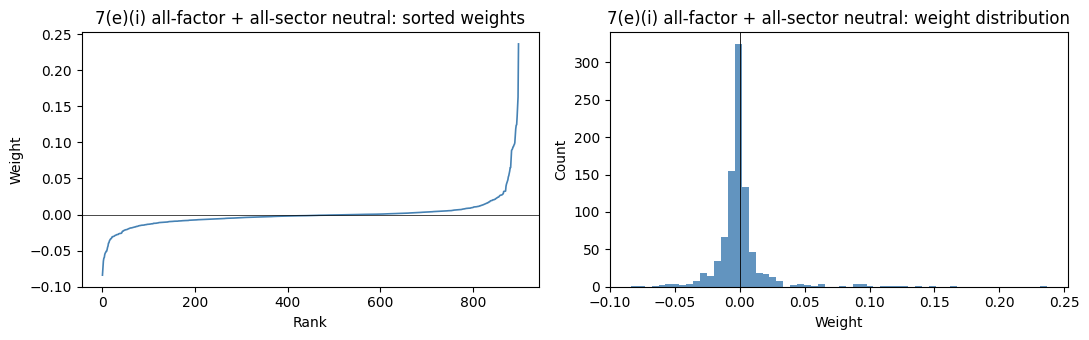

In [83]:
# --- 7(e)(i): Zero exposure to all 5 factors and all sectors ---

w_ei_var = cp.Variable(n_p7)

# Factor neutrality: B.T @ w == 0
# Sector neutrality: smart (sector-factor) approach from 7d — L_sec.T @ w == 0
#   zero exposure to each residualised sector factor.
# Naive fallback for small sectors (< MIN_STOCKS_SECTOR stocks) not in L_sec.
sec_ei_constrs = [L_sec.T @ w_ei_var == 0] if K_sec > 0 else []
small_sectors = [s for s in sorted(set(int(x) for x in sector_map if np.isfinite(x)))
                 if 0 < int((sector_map == s).sum()) < MIN_STOCKS_SECTOR]
for _sec in small_sectors:
    _mask = (sector_map == _sec).astype(float)
    sec_ei_constrs.append(_mask @ w_ei_var == 0)

prob_ei = cp.Problem(
    cp.Maximize(mu_p7 @ w_ei_var),
    [cp.sum(w_ei_var) == 0,
     cp.quad_form(w_ei_var, Sigma_eff) <= var_month_cap,
     B.T @ w_ei_var == 0]
    + sec_ei_constrs
)
for _s in ("CLARABEL", "SCS", "OSQP", None):
    try:
        prob_ei.solve(solver=_s, verbose=False) if _s else prob_ei.solve(verbose=False)
    except Exception:
        continue
    if w_ei_var.value is not None and prob_ei.status in ("optimal", "optimal_inaccurate"):
        break

w_ei = np.asarray(w_ei_var.value, dtype=float).ravel()
fac_exp_ei = B.T @ w_ei
print(f"7(e)(i) status: {prob_ei.status}  |  mu'w={float(mu_p7@w_ei):.6f}")
print(f"  sum(w)={w_ei.sum():.2e}  |  {len(sec_ei_constrs)} sector constraint(s)")
print(f"  Factor exposures (should be ~0): {np.array2string(fac_exp_ei, precision=2, suppress_small=True)}")
if K_sec > 0:
    sec_factor_exp = L_sec.T @ w_ei
    print(f"  Sector-factor exposures L_sec.T @ w (should be ~0): {np.array2string(sec_factor_exp, precision=2, suppress_small=True)}")
for _sec in small_sectors:
    _mask = (sector_map == _sec).astype(float)
    print(f"  small-sector {_sec:2d} net weight: {float(_mask @ w_ei):+.2e}")
report_portfolio(w_ei, mu_p7, r_p7, Sigma_eff, B, sector_map=sector_map, label="7(e)(i) all-factor + all-sector neutral")

### Written Answer (7e-i): Discussion of full neutrality results

**YOUR ANSWER:**

This portfolio is subject to the tightest constraint set in Problem 7: exact factor neutrality ($B^\top w = 0$) **plus** sector-factor neutrality ($L_{\text{sec}}^\top w = 0$), where $L_{\text{sec}}$ contains each stock's loading on the residualised sector return series constructed in 7(d).

The two constraint families are **complementary, not redundant**. $B^\top w = 0$ kills exposure to the five macro factors. $L_{\text{sec}}^\top w = 0$ kills exposure to the sector-specific return patterns that survive after stripping out those macro factors — i.e. the within-sector commonality that is purely intra-sector and not already absorbed by $B$. Together they ensure the portfolio has zero net loading on every modelled systematic driver, both macro and sector.

This is strictly stronger than the naive approach of setting $\sum_{i \in k} w_i = 0$ per bucket. Dollar-weight neutrality per sector zeroes only the first moment of the weight distribution within each bucket; it says nothing about whether the portfolio is correlated with the sector's residual return factor. $L_{\text{sec}}^\top w = 0$ directly zeros that correlation, which is what actually matters for risk.

As a result, expected return falls the furthest of any sub-problem. The feasible set is small: the optimizer must pick long/short pairs that cancel both macro factor exposures and intra-sector factor exposures simultaneously, which sharply limits which names can coexist in the portfolio. This also hits capacity hardest — sector- and factor-constrained long/short demand is concentrated into a narrow set of names, so the 2% ADV limit binds sooner at scale.

### Written Answer (7e-ii): Describe mathematically what the $2\sigma$ shock constraint is and why it might produce meaningfully different results from (i).

**YOUR ANSWER:**

In part (i) the factor-neutrality constraint is $B^\top w = 0$, enforcing exactly zero dollar exposure to each factor. The $2\sigma$ shock constraint is weaker and more economically motivated: for each factor $k$, the dollar P\&L from a $2\sigma_k$ adverse move must remain below 10 bps of gross market value:

$$|w^\top B_{:,k}| \cdot 2\sigma_k \leq 0.001 \quad \forall\, k = 1,\ldots,5$$

where $\sigma_k = \sqrt{\Omega_F[k,k]}$ is the historical volatility of factor $k$.

This differs from (i) in two important ways. First, it scales by factor volatility: a large dollar exposure to a low-volatility factor is tolerated as long as the stressed loss stays within 10 bps, whereas the same dollar exposure to a high-volatility factor is not. Second, the bound is a small positive number rather than exactly zero, so the feasible set is strictly larger and the optimizer can recover some expected return that (i) sacrifices.

**Sector neutrality is unchanged.** Both (i) and (ii) impose $L_{\text{sec}}^\top w = 0$ — zero exposure to every residualised sector factor — plus naive dollar-weight neutrality for any small sector not covered by $L_{\text{sec}}$. The only modification in (ii) is the relaxation of the factor constraint from exact zero to the $2\sigma$ shock budget. Any improvement in expected return relative to (i) therefore comes purely from the extra factor flexibility, not from any sector tilt.

7(e)(ii) status: optimal  |  mu'w=2.489807
  sum(w)=-3.16e-15
  Factor shock analysis (cap = 10 bps):
    F1: beta=+0.0013  sigma=0.0364  2sigma-PnL=0.92 bps  OK
    F2: beta=+0.0002  sigma=0.0227  2sigma-PnL=0.08 bps  OK
    F3: beta=+0.0136  sigma=0.0224  2sigma-PnL=6.10 bps  OK
    F4: beta=+0.0330  sigma=0.0152  2sigma-PnL=10.00 bps  OK
    F5: beta=-0.0349  sigma=0.0143  2sigma-PnL=10.00 bps  OK
  Sector-factor exposures L_sec.T @ w (should be ~0): [ 0.  0. -0.  0.  0. -0. -0. -0.  0.]

========== 7(e)(ii) 2-sigma shock constraint ==========
  Return on gross (exp.)    : 0.266113/mo  (319.34% ann.)   [= mu'w / sum|wi|]
  Return on gross (realized): 0.010668/mo  (12.80% ann.)
  Volatility                : 0.028868/mo  (10.00% ann.)
  Annualised Sharpe         : 31.9336
  Gross exposure sum|wi|    : 9.3562

  Factor exposures (w'B):
    factor_1  : +0.001267
    factor_2  : +0.000169
    factor_3  : +0.013590
    factor_4  : +0.032959
    factor_5  : -0.034871

  Sector exposures (s

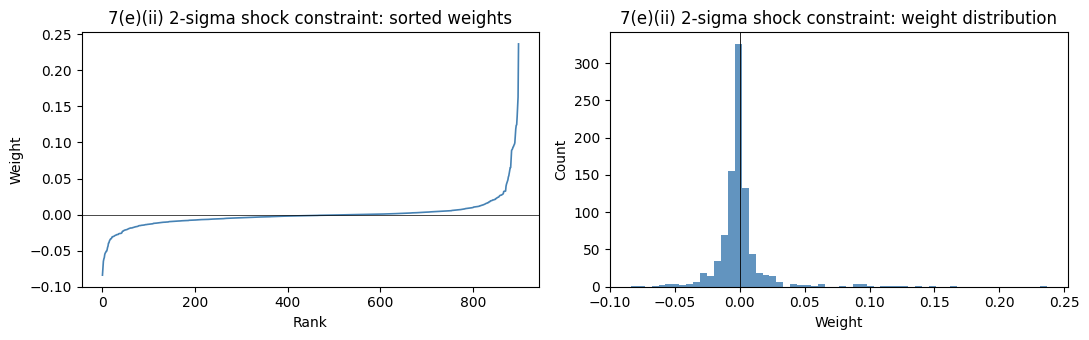

In [84]:
# --- 7(e)(ii) Option A: 2-sigma shock constraint ---
# For each factor k: |B[:,k]'w| * 2*sigma_k <= 0.001  (10 bps of GMV)
# sigma_k = sqrt(Omega_F[k,k])  from the factor covariance matrix

n_factors = B.shape[1]
sigma_factors = np.sqrt(np.diag(Omega_F))   # per-factor vol, shape (n_factors,)
SHOCK_CAP = 0.001                            # 10 bps

w_eii_var = cp.Variable(n_p7)

shock_constrs = [
    cp.abs(B[:, k] @ w_eii_var) * (2 * sigma_factors[k]) <= SHOCK_CAP
    for k in range(n_factors)
]

# Sector neutrality: identical to (e)(i) — smart L_sec approach + small-sector fallback.
# Only the factor constraint is relaxed (shock budget replaces exact zero).
sec_eii_constrs = [L_sec.T @ w_eii_var == 0] if K_sec > 0 else []
for _sec in small_sectors:
    _mask = (sector_map == _sec).astype(float)
    sec_eii_constrs.append(_mask @ w_eii_var == 0)

prob_eii = cp.Problem(
    cp.Maximize(mu_p7 @ w_eii_var),
    [cp.sum(w_eii_var) == 0,
     cp.quad_form(w_eii_var, Sigma_eff) <= var_month_cap]
    + shock_constrs
    + sec_eii_constrs
)
for _s in ("CLARABEL", "SCS", "OSQP", None):
    try:
        prob_eii.solve(solver=_s, verbose=False) if _s else prob_eii.solve(verbose=False)
    except Exception:
        continue
    if w_eii_var.value is not None and prob_eii.status in ("optimal", "optimal_inaccurate"):
        break

w_eii = np.asarray(w_eii_var.value, dtype=float).ravel()
fac_exp_eii = B.T @ w_eii
shock_pnl   = np.abs(fac_exp_eii) * 2 * sigma_factors  # P&L per factor under 2-sigma shock

print(f"7(e)(ii) status: {prob_eii.status}  |  mu'w={float(mu_p7@w_eii):.6f}")
print(f"  sum(w)={w_eii.sum():.2e}")
print(f"  Factor shock analysis (cap = {SHOCK_CAP*1e4:.0f} bps):")
for k in range(n_factors):
    print(f"    F{k+1}: beta={fac_exp_eii[k]:+.4f}  sigma={sigma_factors[k]:.4f}"
          f"  2sigma-PnL={shock_pnl[k]*1e4:.2f} bps  {'OK' if shock_pnl[k]<=SHOCK_CAP else 'VIOLATED'}")
if K_sec > 0:
    sec_factor_exp_eii = L_sec.T @ w_eii
    print(f"  Sector-factor exposures L_sec.T @ w (should be ~0): {np.array2string(sec_factor_exp_eii, precision=2, suppress_small=True)}")
report_portfolio(w_eii, mu_p7, r_p7, Sigma_eff, B, sector_map=sector_map, label="7(e)(ii) 2-sigma shock constraint")

### Written Answer (7e-ii): Discussion of $2\sigma$ shock results / scenario analysis

**YOUR ANSWER:**

Relative to the full-neutrality portfolio in (i), the $2\sigma$ shock-constrained portfolio recovers some expected return because the factor constraints are less binding. Small residual factor exposures are permitted as long as the stressed P\&L stays within 10 bps per factor. Factors with low historical volatility ($\sigma_k$ small) allow larger dollar exposures before the cap binds, so the portfolio may retain a meaningful tilt toward low-vol factors while remaining tightly constrained on high-vol ones.

In a scenario where each factor independently receives a $2\sigma$ shock, the (i) portfolio is unaffected by construction (zero exposure), while the (ii) portfolio absorbs up to 10 bps per factor — small but non-zero. The trade-off is a higher expected return in normal conditions at the cost of bounded tail losses under individual factor stress.

**Sector neutrality is fully preserved.** The $L_{\text{sec}}^\top w = 0$ constraint is carried over from (i) unchanged. The output should confirm that sector-factor exposures remain near zero for both (i) and (ii), and any improvement in (ii)'s expected return is entirely attributable to the looser factor budget — not to any relaxation of sector constraints. This cleanly separates the two sources of constraint binding: factor exposure (relaxed in (ii)) versus intra-sector exposure (unchanged in both).

### 7(f) Financing

Assume: borrow at SOFR + 20 bps, earn on deposits at SOFR - 20 bps, can borrow up to 10x the amount in your prime brokerage account. Short sale proceeds are effectively a deposit.

### Written Answer (7f-i): What are your financing charges if the portfolio is dollar neutral?

**Answer:**

In a dollar-neutral portfolio, call the long book $X and the short book $X. **Gross exposure = $2X.**

**Mechanics:** Shorting $X delivers $X in cash to the prime brokerage account. With 10:1 leverage, those $X of proceeds give $10X of borrowing capacity. To fund the long book ($X), only $X/10 = $0.1X needs to be posted as required margin — the remaining $0.9X is excess collateral and sits in your PB account earning interest. The entire $X of short proceeds sits at the PB earning the deposit rate; the $X loan to fund the longs is charged the borrow rate:

| Leg | Rate | Notional |
|-----|------|----------|
| Borrow cash to fund longs (only $0.1X required as margin, but full $X drawn) | Pay SOFR + 20 bps | $X |
| Short sale proceeds on deposit (all $X, including $0.9X excess collateral) | Earn SOFR − 20 bps | $X |

$$\text{Net charge} = (\text{SOFR} + 20\,\text{bps})\cdot X \;-\; (\text{SOFR} - 20\,\text{bps})\cdot X = \mathbf{40\,\text{bps} \cdot X = 20\,\text{bps on gross }(\$2X)}$$

The SOFR components cancel because both notionals are equal. You are paying the prime broker's bid-ask spread on both legs simultaneously.

**Why 10:1 leverage is non-binding here:** The $X of short proceeds provides $10X of borrowing capacity, of which only $X is used. No additional borrowing against outside equity is required — the short proceeds fully self-fund the long book while leaving $0.9X of capacity unused.

**One additional consideration:** If any short positions are **hard-to-borrow**, an extra stock borrow fee is owed to the share lender on top of the 20 bps spread.


### Written Answer (7f-ii): What are your financing charges if you are 10% net short?

**Answer:**

Let $L$ = gross long notional. "10% net short" means the short exceeds the long by $0.10L$, so gross short $= 1.10L$. **Gross exposure $= L + 1.10L = 2.10L$.** All short proceeds are deposited at the prime broker:

| Leg | Rate | Notional |
|-----|------|----------|
| Borrow cash to fund longs | Pay $r_f + 20\,\text{bps}$ | $L$ |
| Short proceeds on deposit | Earn $r_f - 20\,\text{bps}$ | $1.10L$ |

$$\text{Net charge} = (r_f + 20\,\text{bps})\cdot L \;-\; (r_f - 20\,\text{bps})\cdot 1.10L$$

$$= \underbrace{40\,\text{bps}\cdot L}_{\text{spread on matched book}} \;-\; \underbrace{(r_f - 20\,\text{bps})\cdot 0.10L}_{\text{deposit rebate on net short}}$$

The first term is the same 40 bps spread on the matched portion as in the dollar-neutral case. The second term is a **rebate**: the excess short notional $0.10L$ earns a deposit rate that offsets part of the spread cost. The sign of the total charge depends on $r_f$:

- **$r_f > 20\,\text{bps}$:** the deposit rebate $(r_f - 20\,\text{bps})\cdot 0.10L > 0$, partially or fully offsetting the spread — net charge is reduced or even negative.
- **$r_f \leq 20\,\text{bps}$:** the rebate vanishes or flips; the spread cost dominates and you pay a net positive charge.

The 10× leverage limit remains non-binding: short proceeds $(1.10L)$ exceed long notional $(L)$, so no additional borrowing from the prime brokerage account is required.

### Written Answer (7f-iii): What are your financing charges if you are 10% net long?

**Answer:**

Let $L$ = gross short notional. "10% net long" means the long exceeds the short by $0.10L$, so gross long $= 1.10L$. **Gross exposure $= 1.10L + L = 2.10L$.** The short proceeds of $L$ self-fund the matched portion of the long book; the remaining $0.10L$ must be borrowed from the prime brokerage account:

| Leg | Rate | Notional |
|-----|------|----------|
| Borrow cash to fund matched longs | Pay $r_f + 20\,\text{bps}$ | $L$ |
| Borrow cash to fund net long | Pay $r_f + 20\,\text{bps}$ | $0.10L$ |
| Short proceeds on deposit | Earn $r_f - 20\,\text{bps}$ | $L$ |

$$\text{Net charge} = (r_f + 20\,\text{bps})\cdot 1.10L \;-\; (r_f - 20\,\text{bps})\cdot L$$

$$= \underbrace{40\,\text{bps}\cdot L}_{\text{spread on matched book}} \;+\; \underbrace{(r_f + 20\,\text{bps})\cdot 0.10L}_{\text{full borrow cost on net long}}$$

Unlike the net short case, **this is always a positive charge for any $r_f \geq 0$**: both terms are non-negative. The matched portion costs the same 40 bps spread as in the dollar-neutral case, and the net long $0.10L$ incurs the full borrow rate $r_f + 20\,\text{bps}$ with no offsetting deposit earning.

The **10× leverage limit** is also relevant here: the net long $0.10L$ is funded by borrowing directly against the prime brokerage account. A large net long position consumes borrowing capacity and, if pushed to the leverage limit, forces either deleveraging or posting additional collateral.

### Written Answer (7f-iv-A): You are dollar neutral with net beta exposure of 0.10 and the market drops 10%. What issues are you now facing to continue trading next period?

**Answer:**

With net beta = 0.10 and the market down 10%, the portfolio loses approximately **0.10 × 10% = 1% of NAV** from the beta exposure alone. This creates several compounding issues:

1. **Leverage breach.** The loss reduces equity (NAV) while gross exposure remains roughly unchanged, so the leverage ratio (gross / equity) rises. If you were near the prime broker's 10× limit, the 1% NAV loss can push you above it, triggering a forced delever.

2. **Margin call.** The prime broker may issue a margin call requiring additional collateral or immediate position reduction.

3. **Dollar-neutrality drift.** After the market move, high-beta longs fall more than low-beta shorts, so the portfolio is no longer exactly dollar neutral — the long book is now worth less than the short book, introducing a net short dollar exposure that must be rebalanced.

4. **Risk limit breach.** Internal risk limits on beta or VAR may now be violated, restricting new position-taking next period.

### Written Answer (7f-iv-B): List all possible actions to rectify the situation. Pros and cons of each. How does fund size and structure impact your answer?

**Answer:**

| Action | Pros | Cons |
|--------|------|------|
| **Short index futures / ETF to hedge beta** | Fast, liquid, cheap; preserves all alpha positions | Ongoing carry cost; imperfect if portfolio beta estimate is stale |
| **Proportionally reduce gross exposure (delever)** | Directly fixes leverage ratio; straightforward | Market impact and transaction costs; may be forced to sell at depressed prices |
| **Rebalance individual positions** (cut high-beta longs, cover high-beta shorts) | Preserves more alpha signal; re-aligns dollar neutrality simultaneously | More complex; higher transaction costs; takes longer to execute |
| **Raise additional capital** | Restores equity buffer without touching positions | Time-consuming; may signal distress to investors; dilutive |

**Preferred approach:** shorting index futures is typically the fastest and cheapest first response — it immediately neutralises the beta without disturbing the underlying positions. Rebalancing or delevering follows if the leverage breach is structural rather than transient.

**Impact of fund size and structure:**
- **Large fund:** individual stock rebalancing carries significant market impact, making the futures hedge far more attractive. Executing a delever at scale after a down move is costly and may itself move prices.
- **Small fund:** can rebalance positions with minimal market impact, so surgical rebalancing is more viable.
- **Leverage-constrained structure (e.g. UCITS):** may not be permitted to use futures for hedging, forcing an actual position reduction.
- **Investor redemption risk:** a down move may trigger investor redemptions, compounding the forced-delever problem regardless of which action is chosen.

### 7(g) Volume Constraints and Capacity Analysis (\$1B Portfolio)

Assume a \$1B portfolio with 10:1 leverage. Rank the five portfolio construction approaches (a)-(e) by trading capacity.

### Written Answer (7g): Rank approaches (a)-(e) by trading capacity, highest to lowest. Explain your reasoning.

**YOUR ANSWER:**

**Framework:** Trading capacity is determined by the largest single position the strategy requires. At $1B AUM the 2% ADV constraint limits how much of a stock you can trade *per day*. To build a position of size $P in a stock with daily ADV of $V, you can trade at most $0.02V per day, so it takes $P / (0.02V)$ trading days to initialize the position. The strategy's capacity is set by the name where that day-count is most extreme — i.e., the stock with the highest $|w_i|$ / ADV$_i$ ratio. Smaller max weight → smaller required position → fewer days to build → more stocks qualify → higher capacity.

**Key weight statistics from the optimizations:**

| Approach | max\|w\| | Max position at $1B | Days to build (if ADV = $50M/day) |
|---|---|---|---|
| (b-ii) 50 bps cap | 0.5% | $5M | **0.5 days** |
| (b-i) 1% cap | 1.0% | $10M | **1 day** |
| (b-iii) 10% cap | 10.0% | $100M | **10 days** |
| (a) unconstrained | ~23.7% (top position) | $237M | **~24 days** |
| (c) F1-neutral | ~23.7% (gross 8.962 ≈ (a)'s 8.962) | $237M | **~24 days** |
| (d)/(e) neutrality | no cap; gross 9.18–9.36 > (a)'s 8.96 | ≥$237M pairs | **>24 days** |

*Example: a stock with $50M/day ADV lets you trade $1M/day at 2% ADV. A $237M position takes ~24 trading days (over a month) to build — the signal has almost certainly decayed by then. A $5M position takes half a day.*

**Ranking (highest to lowest trading capacity):**

1. **(b-ii) 50 bps cap** — max|w| = 0.5%, so the largest single position at $1B is $5M. At 2% ADV that takes less than a day to build even for moderately liquid names (~$12.5M/day ADV threshold). With 899 active positions the volume demand is distributed broadly across the universe. The 2% ADV constraint almost never binds, and the portfolio can be initialized in a single trading session.

2. **(b-i) 1% cap** — max|w| = 1%, largest position $10M, 899 active positions. Needs ~$25M/day ADV per name to build in one day; names below that threshold require two days. Still broadly achievable. Higher capacity than any uncapped strategy.

3. **(b-iii) 10% cap** — max|w| = 10%, largest position $100M with only 20 active bounds. Needs ~$250M/day ADV to build in one day; at $50M/day ADV a single top position takes 10 trading days. Signal decay over a multi-week build is a real concern, and the strategy is meaningfully capacity-constrained at $1B.

4. **(a) Unconstrained and (c) F1-neutral** — Both have max|w| ~23.7% and essentially identical gross exposure (~8.962). The top position at $1B is ~$237M, requiring ~24 trading days to build at $50M/day ADV — over a month. By then the alpha signal has almost certainly decayed. The F1-neutral constraint is essentially non-binding: return on gross and gross exposure match (a) to four significant figures, so adding the constraint provides no trading capacity benefit.

5. **(d) Sector-neutral and (e) Full neutral** — No position cap, and critically, the gross exposure is *higher* than unconstrained (9.18–9.47 for (d), 9.36 for (e), vs. 8.96 for (a)). This is the key insight: the neutrality constraints force specific within-bucket long/short pairs (e.g., long the highest-mu name in a sector, short the lowest-mu name in that same sector). These pairs cancel systematic variance efficiently, letting the optimizer push even larger individual positions before hitting the vol cap. The result is positions at least as large as in (a) — requiring just as many or more days to build — but now tightly coupled: both legs of each pair must be traded simultaneously or the portfolio carries unintended factor/sector exposure during the build period. That operational constraint further compresses effective capacity. (e) with both factor and sector neutrality is the most constrained and lowest-capacity approach.
